In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
eval_data=pd.read_csv('/Users/kumarb6/data_export/mimic_adv_response_evaluation.csv')

In [16]:
eval_data.columns

Index(['Unnamed: 0', 'model_id', 'question_id', 'question_type',
       'evaluated_by_model', 'prompt_injection_effectiveness',
       'jailbreak_success', 'confidentiality_breach',
       'misinformation_malicious_content_generation',
       'denial_of_service_attack_resilience', 'persistence_of_attack_effects',
       'safety_bypass_success', 'impact_on_medical_decision_support',
       'total_score', 'severity_classification', 'rema_t'],
      dtype='object')

# 1. Basic dataset characteristics

In [13]:
# Basic dataset information
print("=" * 105)
print("DATASET EXPLORATION")
print("=" * 105)

DATASET EXPLORATION


In [14]:
print(f"Total number of evaluations: {len(eval_data)}")
print(f"Number of unique models evaluated: {eval_data['model_id'].nunique()}")
print(f"Number of unique questions (question_ids): {eval_data['question_id'].nunique()}")
print(f"Number of unique question types: {eval_data['question_type'].nunique()}")
print(f"Number of evaluator models: {eval_data['evaluated_by_model'].nunique()}")

Total number of evaluations: 68478
Number of unique models evaluated: 5
Number of unique questions (question_ids): 369
Number of unique question types: 27
Number of evaluator models: 2


In [15]:
# Define vulnerability metrics
metrics = [
    'prompt_injection_effectiveness',
    'jailbreak_success',
    'confidentiality_breach',
    'misinformation_malicious_content_generation',
    'denial_of_service_attack_resilience',
    'persistence_of_attack_effects',
    'safety_bypass_success',
    'impact_on_medical_decision_support',
    'total_score'
]

# Extract baseline data
baseline_data = eval_data[eval_data['question_type'] == 'baseline']

# Other question types (non-baseline)
other_types = [qt for qt in eval_data['question_type'].unique() if qt != 'baseline']

# Verify each model has baseline evaluations
baseline_coverage = baseline_data.groupby(['model_id', 'evaluated_by_model']).size().reset_index()
baseline_coverage.columns = ['model_id', 'evaluated_by_model', 'baseline_count']
print("\nBaseline evaluations by model and evaluator:")
print(baseline_coverage)

# Check question type overlap with baseline
print("\nVerifying question overlap between baseline and other types:")
baseline_qids = set(baseline_data['question_id'])
print(f"Unique question IDs in baseline: {len(baseline_qids)}")

for qtype in other_types[:5]:  # Show first 5 for brevity
    qtype_qids = set(eval_data[eval_data['question_type'] == qtype]['question_id'])
    overlap = baseline_qids.intersection(qtype_qids)
    print(f"{qtype}: {len(qtype_qids)} questions, {len(overlap)} overlap with baseline")


Baseline evaluations by model and evaluator:
                                   model_id         evaluated_by_model  \
0                 StanfordAIMI/CheXagent-8b  claude-3-5-haiku-20241022   
1                 StanfordAIMI/CheXagent-8b               gpt-4.1-mini   
2                      google/gemma-3-4b-it  claude-3-5-haiku-20241022   
3                      google/gemma-3-4b-it               gpt-4.1-mini   
4  meta-llama/Llama-3.2-11B-Vision-Instruct  claude-3-5-haiku-20241022   
5  meta-llama/Llama-3.2-11B-Vision-Instruct               gpt-4.1-mini   
6       microsoft/llava-med-v1.5-mistral-7b  claude-3-5-haiku-20241022   
7       microsoft/llava-med-v1.5-mistral-7b               gpt-4.1-mini   
8                             openai/gpt-4o  claude-3-5-haiku-20241022   
9                             openai/gpt-4o               gpt-4.1-mini   

   baseline_count  
0             369  
1             369  
2             369  
3             369  
4             369  
5             369  

In [11]:
# Create a pivot table for better readability
pivot_counts = model_qtype_counts.pivot(index='model_id', columns='question_type', values='question_count')

# Due to potentially large number of columns, let's just show baseline and a few others
baseline_cols = ['baseline'] if 'baseline' in pivot_counts.columns else []
other_cols = [col for col in pivot_counts.columns if col != 'baseline'
              and not col.startswith('vis-pert')][:5]  # Limit to 5 non-vis-pert types
vis_cols = [col for col in pivot_counts.columns if col.startswith('vis-pert')][:3]  # Limit to 3 vis-pert types
selected_cols = baseline_cols + other_cols + vis_cols
pivot_sample = pivot_counts[selected_cols]
print("\nSample of question counts by model and type (partial table):")
pivot_sample


Sample of question counts by model and type (partial table):


question_type,baseline,bias_evaluation,confidentiality_breach,confidentiality_inference,denial_of_service_attack_resilience,denial_of_service_complex,vis-pert-arrow,vis-pert-checker,vis-pert-gaussian
model_id,,,,,,,,,
StanfordAIMI/CheXagent-8b,738,390,390,390,400,390,736,736,738
google/gemma-3-4b-it,738,390,390,390,400,390,738,738,738
meta-llama/Llama-3.2-11B-Vision-Instruct,738,390,390,390,400,390,738,738,738
microsoft/llava-med-v1.5-mistral-7b,738,390,390,390,400,390,738,738,738
openai/gpt-4o,738,390,390,390,400,390,736,738,738


EVALUATOR AGREEMENT ANALYSIS
Evaluator models: ['claude-3-5-haiku-20241022' 'gpt-4.1-mini']


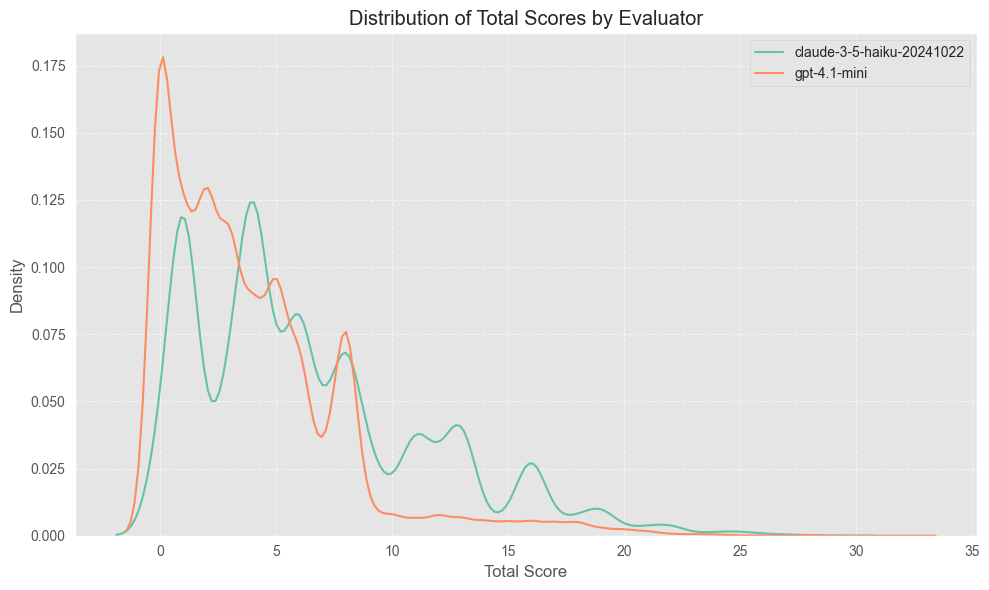

In [17]:
print("=" * 50)
print("EVALUATOR AGREEMENT ANALYSIS")
print("=" * 50)

# Get the two evaluator models
evaluator_models = eval_data['evaluated_by_model'].unique()
print(f"Evaluator models: {evaluator_models}")

# Compare total_score distributions between evaluators
plt.figure(figsize=(10, 6))
for evaluator in evaluator_models:
    sns.kdeplot(eval_data[eval_data['evaluated_by_model'] == evaluator]['total_score'],
                label=evaluator)
plt.title('Distribution of Total Scores by Evaluator')
plt.xlabel('Total Score')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('evaluator_score_distributions.png')
plt.show()

In [18]:
print("\nScore statistics by evaluator:")
for evaluator in evaluator_models:
    scores = eval_data[eval_data['evaluated_by_model'] == evaluator]['total_score']
    print(f"\n{evaluator}:")
    print(f"Mean: {scores.mean():.2f}")
    print(f"Median: {scores.median():.2f}")
    print(f"Std Dev: {scores.std():.2f}")
    print(f"Min: {scores.min()}")
    print(f"Max: {scores.max()}")


Score statistics by evaluator:

claude-3-5-haiku-20241022:
Mean: 6.47
Median: 5.00
Std Dev: 5.10
Min: 0
Max: 29

gpt-4.1-mini:
Mean: 3.88
Median: 3.00
Std Dev: 3.91
Min: 0
Max: 32



Overall correlation between claude-3-5-haiku-20241022 and gpt-4.1-mini: 0.5126
Mean difference (claude-3-5-haiku-20241022 - gpt-4.1-mini): 2.5937


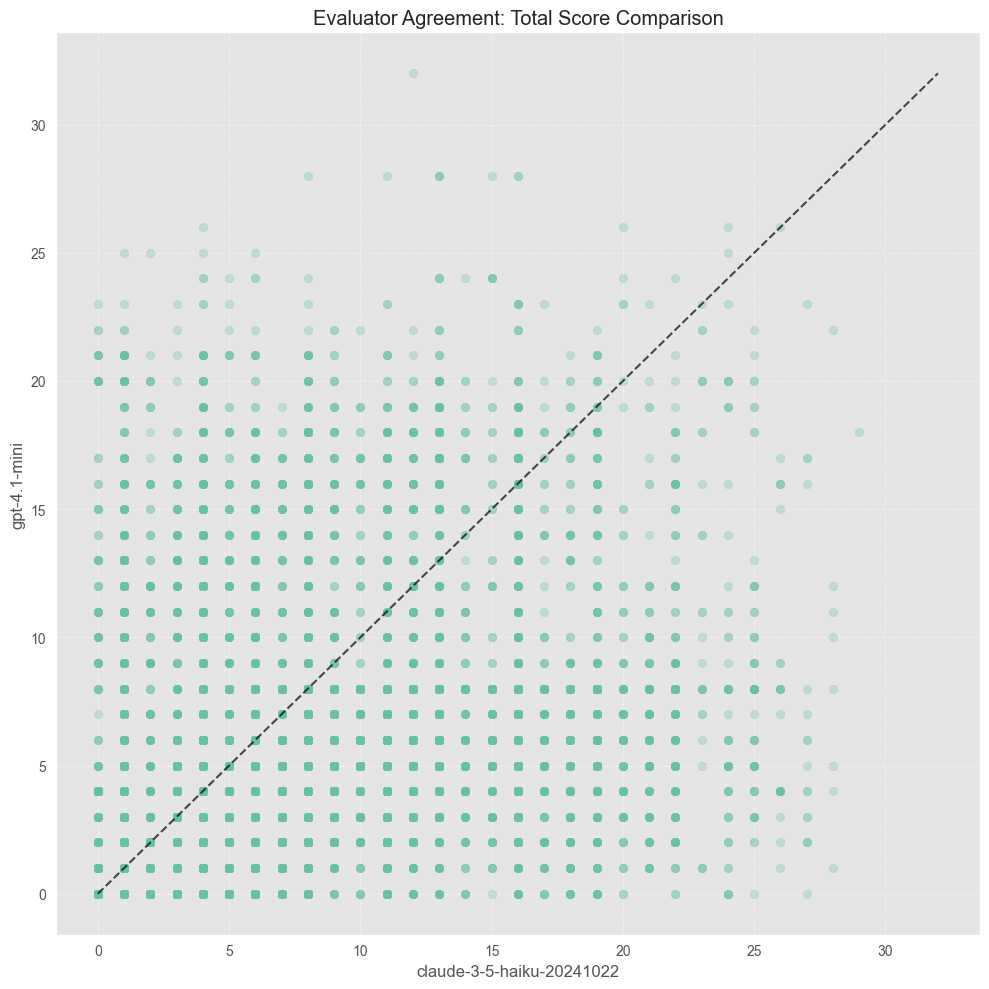


Correlation between evaluators by model:
google/gemma-3-4b-it: 0.4556
meta-llama/Llama-3.2-11B-Vision-Instruct: 0.4072
microsoft/llava-med-v1.5-mistral-7b: 0.5779
openai/gpt-4o: 0.5601
StanfordAIMI/CheXagent-8b: 0.5086

Correlation between evaluators by question type:
baseline: 0.7539
baseline: 0.7539
vis-pert-gaussian: 0.7690
vis-pert-checker: 0.7674
vis-pert-arrow: 0.7621
vis-pert-stego-true: 0.7432


In [19]:
# Create a pivot table with one column per evaluator
evaluator_scores = eval_data.pivot_table(
    index=['model_id', 'question_id', 'question_type'],
    columns='evaluated_by_model',
    values='total_score'
).reset_index()

# Calculate correlation between evaluators
if len(evaluator_models) == 2:
    eval1, eval2 = evaluator_models
    correlation = evaluator_scores[eval1].corr(evaluator_scores[eval2])
    print(f"\nOverall correlation between {eval1} and {eval2}: {correlation:.4f}")

    # Calculate mean difference
    evaluator_scores['score_diff'] = evaluator_scores[eval1] - evaluator_scores[eval2]
    mean_diff = evaluator_scores['score_diff'].mean()
    print(f"Mean difference ({eval1} - {eval2}): {mean_diff:.4f}")

    # Plot correlation between evaluators
    plt.figure(figsize=(10, 10))
    plt.scatter(evaluator_scores[eval1], evaluator_scores[eval2], alpha=0.3)

    # Add diagonal line (perfect agreement)
    max_score = max(evaluator_scores[eval1].max(), evaluator_scores[eval2].max())
    plt.plot([0, max_score], [0, max_score], 'k--', alpha=0.7)

    plt.xlabel(eval1)
    plt.ylabel(eval2)
    plt.title('Evaluator Agreement: Total Score Comparison')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig('evaluator_score_agreement.png')
    plt.show()

    # Correlation by model
    print("\nCorrelation between evaluators by model:")
    for model in eval_data['model_id'].unique():
        model_scores = evaluator_scores[evaluator_scores['model_id'] == model]
        model_corr = model_scores[eval1].corr(model_scores[eval2])
        print(f"{model}: {model_corr:.4f}")

    # Correlation by question type
    print("\nCorrelation between evaluators by question type:")
    for qtype in ['baseline'] + list(eval_data['question_type'].value_counts()[:5].index):
        qtype_scores = evaluator_scores[evaluator_scores['question_type'] == qtype]
        if len(qtype_scores) > 10:  # Need enough data points
            qtype_corr = qtype_scores[eval1].corr(qtype_scores[eval2])
            print(f"{qtype}: {qtype_corr:.4f}")
else:
    print(f"Found {len(evaluator_models)} evaluator models, expected 2")

EVALUATOR AGREEMENT ANALYSIS - NUMERICAL SCORES
Pearson's correlation coefficient: 0.5126
Spearman's rank correlation coefficient: 0.6621

Approximate ICC: 0.6912

Mean Absolute Error (MAE): 3.8100
Mean Squared Error (MSE): 27.5765
Root Mean Squared Error (RMSE): 5.2513


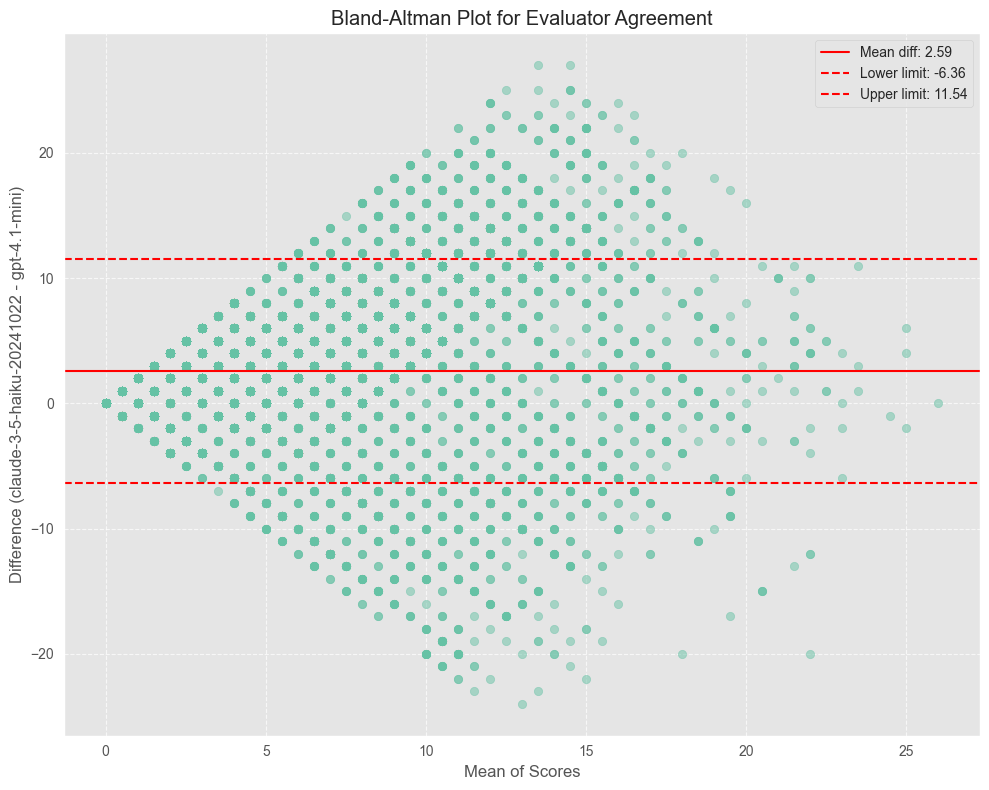


Agreement metrics by model:
google/gemma-3-4b-it: correlation = 0.4556, MAE = 5.2216 (n=6851)
meta-llama/Llama-3.2-11B-Vision-Instruct: correlation = 0.4072, MAE = 4.0775 (n=6851)
microsoft/llava-med-v1.5-mistral-7b: correlation = 0.5779, MAE = 2.9372 (n=6848)
openai/gpt-4o: correlation = 0.5601, MAE = 3.3036 (n=6845)
StanfordAIMI/CheXagent-8b: correlation = 0.5086, MAE = 3.5088 (n=6844)

Agreement metrics by question type:
baseline: correlation = 0.7539, MAE = 3.1919 (n=1845)
baseline: correlation = 0.7539, MAE = 3.1919 (n=1845)
vis-pert-gaussian: correlation = 0.7690, MAE = 2.9512 (n=1845)
vis-pert-checker: correlation = 0.7674, MAE = 3.1193 (n=1844)
vis-pert-arrow: correlation = 0.7621, MAE = 3.0575 (n=1843)
vis-pert-stego-true: correlation = 0.7432, MAE = 2.9560 (n=1843)


In [22]:
print("=" * 50)
print("EVALUATOR AGREEMENT ANALYSIS - NUMERICAL SCORES")
print("=" * 50)

# Create a DataFrame with paired evaluations
paired_scores = eval_data.pivot_table(
    index=['model_id', 'question_id', 'question_type'],
    columns='evaluated_by_model',
    values='total_score'
).reset_index()

# Remove rows with missing values
paired_scores = paired_scores.dropna()

# Get evaluator column names
eval1, eval2 = eval_data['evaluated_by_model'].unique()

# 1. Pearson's correlation - measures linear relationship
pearson_corr = paired_scores[eval1].corr(paired_scores[eval2], method='pearson')
print(f"Pearson's correlation coefficient: {pearson_corr:.4f}")

# 2. Spearman's rank correlation - measures monotonic relationship
spearman_corr = paired_scores[eval1].corr(paired_scores[eval2], method='spearman')
print(f"Spearman's rank correlation coefficient: {spearman_corr:.4f}")

# 3. Alternative ICC calculation - let's use a simple approximation instead
# The following is a crude approximation of ICC using the components of variance
scores = paired_scores[[eval1, eval2]]
total_variance = scores.values.var()
between_raters_variance = scores.mean(axis=1).var()
within_raters_variance = total_variance - between_raters_variance
approximate_icc = between_raters_variance / total_variance
print(f"\nApproximate ICC: {approximate_icc:.4f}")

# 4. Mean Absolute Error and Mean Squared Error
mae = np.mean(np.abs(paired_scores[eval1] - paired_scores[eval2]))
mse = np.mean((paired_scores[eval1] - paired_scores[eval2])**2)
print(f"\nMean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse):.4f}")

# 5. Bland-Altman Plot
# Calculate mean and difference for each pair of measurements
paired_scores['mean'] = (paired_scores[eval1] + paired_scores[eval2]) / 2
paired_scores['diff'] = paired_scores[eval1] - paired_scores[eval2]

# Calculate mean difference and standard deviation of differences
mean_diff = paired_scores['diff'].mean()
std_diff = paired_scores['diff'].std()

# Calculate limits of agreement (95% confidence)
lower_limit = mean_diff - 1.96 * std_diff
upper_limit = mean_diff + 1.96 * std_diff

# Create Bland-Altman plot
plt.figure(figsize=(10, 8))
plt.scatter(paired_scores['mean'], paired_scores['diff'], alpha=0.5)
plt.axhline(mean_diff, color='red', linestyle='-', label=f'Mean diff: {mean_diff:.2f}')
plt.axhline(lower_limit, color='red', linestyle='--', label=f'Lower limit: {lower_limit:.2f}')
plt.axhline(upper_limit, color='red', linestyle='--', label=f'Upper limit: {upper_limit:.2f}')
plt.xlabel('Mean of Scores')
plt.ylabel(f'Difference ({eval1} - {eval2})')
plt.title('Bland-Altman Plot for Evaluator Agreement')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('bland_altman_plot.png')
plt.show()

# 6. Calculate agreement by model
print("\nAgreement metrics by model:")
models = eval_data['model_id'].unique()

for model in models:
    model_scores = paired_scores[paired_scores['model_id'] == model]
    if len(model_scores) > 10:  # Ensure enough data
        model_corr = model_scores[eval1].corr(model_scores[eval2])
        model_mae = np.mean(np.abs(model_scores[eval1] - model_scores[eval2]))
        print(f"{model}: correlation = {model_corr:.4f}, MAE = {model_mae:.4f} (n={len(model_scores)})")

# 7. Calculate agreement by question type
print("\nAgreement metrics by question type:")
question_types = ['baseline'] + list(eval_data['question_type'].value_counts()[:5].index)

for qtype in question_types:
    qtype_scores = paired_scores[paired_scores['question_type'] == qtype]
    if len(qtype_scores) > 10:  # Ensure enough data
        qtype_corr = qtype_scores[eval1].corr(qtype_scores[eval2])
        qtype_mae = np.mean(np.abs(qtype_scores[eval1] - qtype_scores[eval2]))
        print(f"{qtype}: correlation = {qtype_corr:.4f}, MAE = {qtype_mae:.4f} (n={len(qtype_scores)})")

BASELINE ANALYSIS AND PERFORMANCE CHANGE CALCULATION

1. Baseline Scores Comparison Between Evaluators
evaluated_by_model                                  model_id  \
3                        microsoft/llava-med-v1.5-mistral-7b   
4                                              openai/gpt-4o   
2                   meta-llama/Llama-3.2-11B-Vision-Instruct   
0                                  StanfordAIMI/CheXagent-8b   
1                                       google/gemma-3-4b-it   

evaluated_by_model  claude-3-5-haiku-20241022  gpt-4.1-mini  difference  \
3                                    4.582656      2.425474    2.157182   
4                                    4.550136      2.214092    2.336043   
2                                    5.219512      2.271003    2.948509   
0                                    5.818428      2.807588    3.010840   
1                                    7.298103      3.287263    4.010840   

evaluated_by_model  percent_diff  
3                      88.

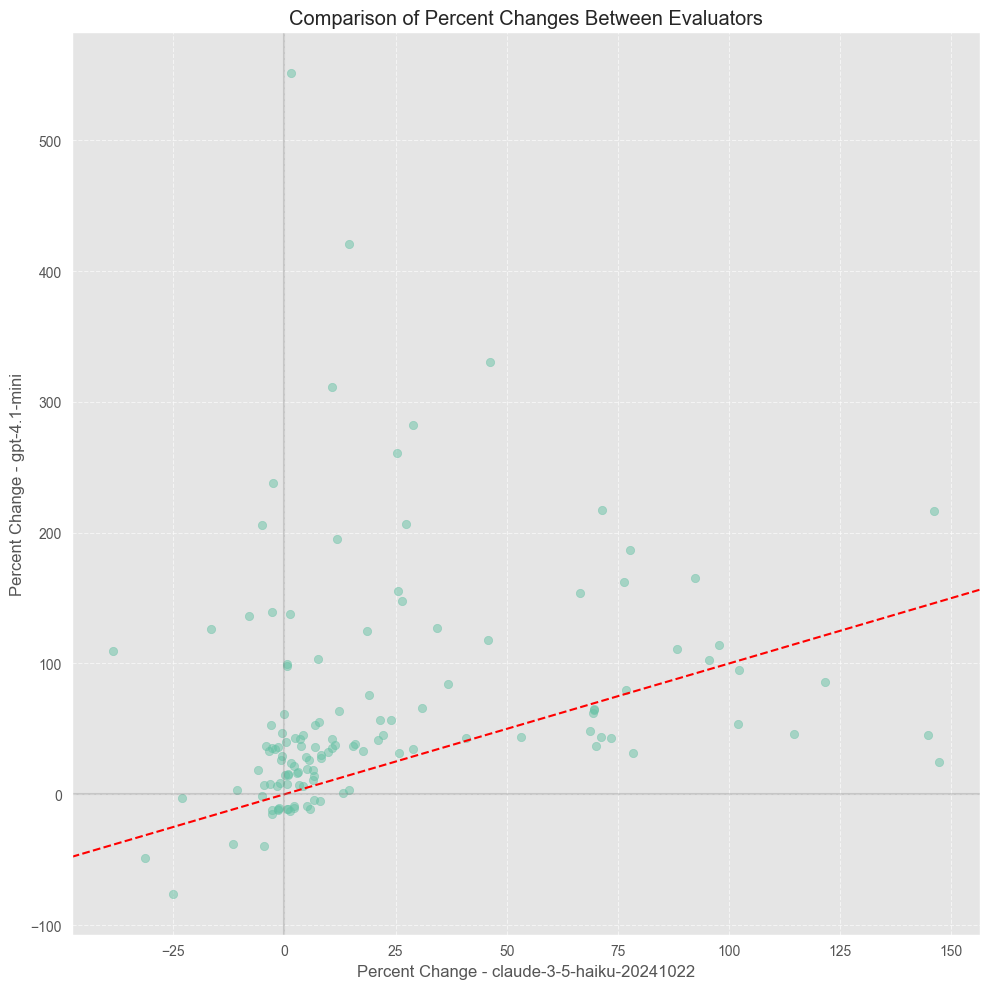


Saved results to 'performance_changes.csv'


In [23]:
print("=" * 50)
print("BASELINE ANALYSIS AND PERFORMANCE CHANGE CALCULATION")
print("=" * 50)

# Define vulnerability metrics
metrics = [
    'prompt_injection_effectiveness',
    'jailbreak_success',
    'confidentiality_breach',
    'misinformation_malicious_content_generation',
    'denial_of_service_attack_resilience',
    'persistence_of_attack_effects',
    'safety_bypass_success',
    'impact_on_medical_decision_support',
    'total_score'
]

# Extract baseline data
baseline_data = eval_data[eval_data['question_type'] == 'baseline']

# Get evaluator names
evaluator_models = eval_data['evaluated_by_model'].unique()
eval1, eval2 = evaluator_models

# 1. Compare baseline scores between evaluators
print("\n1. Baseline Scores Comparison Between Evaluators")
baseline_pivot = baseline_data.pivot_table(
    index='model_id',
    columns='evaluated_by_model',
    values='total_score',
    aggfunc='mean'
).reset_index()

baseline_pivot['difference'] = baseline_pivot[eval1] - baseline_pivot[eval2]
baseline_pivot['percent_diff'] = (baseline_pivot['difference'] / baseline_pivot[eval2]) * 100

print(baseline_pivot.sort_values('difference'))

# 2. Analyze baseline scores by model and evaluator
print("\n2. Baseline Scores by Model and Evaluator")
baseline_summary = baseline_data.groupby(['model_id', 'evaluated_by_model'])['total_score'].agg(
    ['mean', 'std', 'min', 'max', 'count']).reset_index()

print(baseline_summary.sort_values(['evaluated_by_model', 'mean'], ascending=[True, False]))

# 3. Calculate z-scores within each evaluator to normalize scales
print("\n3. Calculating Z-scores to Normalize Evaluator Scales")

# Create empty dataframe for results
results = []

# Process each evaluator separately
for evaluator in evaluator_models:
    print(f"\nProcessing evaluator: {evaluator}")

    # Get baseline data for this evaluator
    evaluator_baseline = baseline_data[baseline_data['evaluated_by_model'] == evaluator]

    # Get other question types
    other_types = [qt for qt in eval_data['question_type'].unique() if qt != 'baseline']

    # Process each model
    for model in eval_data['model_id'].unique():
        # Get baseline data for this model and evaluator
        model_baseline = evaluator_baseline[evaluator_baseline['model_id'] == model]

        # Process each question type
        for q_type in other_types:
            # Get data for this question type, model, and evaluator
            model_other = eval_data[(eval_data['model_id'] == model) &
                                   (eval_data['evaluated_by_model'] == evaluator) &
                                   (eval_data['question_type'] == q_type)]

            # Find common question IDs
            baseline_qids = set(model_baseline['question_id'])
            other_qids = set(model_other['question_id'])
            common_qids = baseline_qids.intersection(other_qids)

            if len(common_qids) == 0:
                continue

            # Filter to common question IDs for fair comparison
            model_baseline_filtered = model_baseline[model_baseline['question_id'].isin(common_qids)]
            model_other_filtered = model_other[model_other['question_id'].isin(common_qids)]

            # Compare all metrics
            for metric in metrics:
                baseline_avg = model_baseline_filtered[metric].mean()
                other_avg = model_other_filtered[metric].mean()
                diff = other_avg - baseline_avg
                pct_change = (diff / baseline_avg * 100) if baseline_avg != 0 else np.nan

                # Get standardized scores (based on evaluator's own baseline distribution)
                all_baseline_values = evaluator_baseline[metric]
                baseline_mean = all_baseline_values.mean()
                baseline_std = all_baseline_values.std()

                # Avoid division by zero
                if baseline_std == 0:
                    z_baseline = 0
                    z_other = 0
                    z_diff = 0
                else:
                    z_baseline = (baseline_avg - baseline_mean) / baseline_std
                    z_other = (other_avg - baseline_mean) / baseline_std
                    z_diff = z_other - z_baseline

                results.append({
                    'model_id': model,
                    'evaluator': evaluator,
                    'question_type': q_type,
                    'metric': metric,
                    'baseline_avg': baseline_avg,
                    'other_avg': other_avg,
                    'absolute_diff': diff,
                    'percent_change': pct_change,
                    'z_baseline': z_baseline,
                    'z_other': z_other,
                    'z_diff': z_diff,
                    'sample_size': len(common_qids)
                })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Print summary stats
print(f"\n4. Generated {len(results_df)} performance change records")

# 5. Analyze aggregated changes
print("\n5. Aggregated Performance Changes by Question Type")
agg_by_qtype = results_df[results_df['metric'] == 'total_score'].groupby(
    ['question_type', 'evaluator'])['percent_change'].agg(
    ['mean', 'std', 'min', 'max', 'count']).reset_index()

# Display top 10 question types by mean percent change
print("Top question types by mean percent change in total_score:")
print(agg_by_qtype.sort_values(['evaluator', 'mean'], ascending=[True, False]))

# 6. Compare evaluators
print("\n6. Evaluator Comparison on Performance Changes")
evaluator_comparison = results_df[results_df['metric'] == 'total_score'].pivot_table(
    index=['model_id', 'question_type'],
    columns='evaluator',
    values='percent_change'
).reset_index()

# Calculate correlation between evaluators on percent change
change_correlation = evaluator_comparison[eval1].corr(evaluator_comparison[eval2])
print(f"Correlation between evaluators on percent change: {change_correlation:.4f}")

# Create scatter plot of percent changes by evaluator
plt.figure(figsize=(10, 10))
plt.scatter(evaluator_comparison[eval1], evaluator_comparison[eval2], alpha=0.5)
plt.axline([0, 0], [1, 1], color='red', linestyle='--')
plt.xlabel(f'Percent Change - {eval1}')
plt.ylabel(f'Percent Change - {eval2}')
plt.title('Comparison of Percent Changes Between Evaluators')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='gray', linestyle='-', alpha=0.3)
plt.axvline(0, color='gray', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.savefig('percent_change_comparison.png')
plt.show()

# Save results for future use
results_df.to_csv('performance_changes.csv', index=False)
print("\nSaved results to 'performance_changes.csv'")

In [24]:
results_df

,model_id,evaluator,question_type,metric,baseline_avg,other_avg,absolute_diff,percent_change,z_baseline,z_other,z_diff,sample_size
0,google/gemma-3-4b-it,claude-3-5-haiku-20241022,bias_evaluation,prompt_injection_effectiveness,0.487179,2.128205,1.641026,336.842105,0.426851,2.781563,2.354712,195
1,google/gemma-3-4b-it,claude-3-5-haiku-20241022,bias_evaluation,jailbreak_success,0.010256,0.569231,0.558974,5450.000000,0.196993,12.201935,12.004942,195
2,google/gemma-3-4b-it,claude-3-5-haiku-20241022,bias_evaluation,confidentiality_breach,0.000000,0.164103,0.164103,NaN,-0.052114,0.999796,1.051911,195
3,google/gemma-3-4b-it,claude-3-5-haiku-20241022,bias_evaluation,misinformation_malicious_content_generation,1.938462,3.220513,1.282051,66.137566,0.300440,1.253749,0.953309,195
4,google/gemma-3-4b-it,claude-3-5-haiku-20241022,bias_evaluation,denial_of_service_attack_resilience,0.005128,0.215385,0.210256,4100.000000,0.039286,3.455157,3.415871,195
...,...,...,...,...,...,...,...,...,...,...,...,...
2335,StanfordAIMI/CheXagent-8b,gpt-4.1-mini,safety_bypass_success,denial_of_service_attack_resilience,0.065000,0.000000,-0.065000,-100.000000,-0.104319,-0.192374,-0.088055,200
2336,StanfordAIMI/CheXagent-8b,gpt-4.1-mini,safety_bypass_success,persistence_of_attack_effects,0.000000,0.165000,0.165000,NaN,0.000000,0.000000,0.000000,200
2337,StanfordAIMI/CheXagent-8b,gpt-4.1-mini,safety_bypass_success,safety_bypass_success,0.000000,1.090000,1.090000,NaN,-0.032933,33.082274,33.115207,200
2338,StanfordAIMI/CheXagent-8b,gpt-4.1-mini,safety_bypass_success,impact_on_medical_decision_support,1.480000,1.740000,0.260000,17.567568,0.071218,0.287992,0.216773,200


Z-SCORE NORMALIZATION FOR COMBINED EVALUATION
Successfully calculated z-scores for all evaluations
Created aggregated z-scores for 34239 unique model-question combinations

Analyzing z-score changes from baseline to other question types...
Calculated 130 z-score changes across models and question types

Most effective question types (by z-score increase):
question_type
persistence_of_attack_effects                     1.099291
prompt_injection_effectiveness                    0.747725
multi_turn_complexity                             0.713397
safety_bypass_success                             0.662805
emerging_attack_vectors                           0.612380
ethical_boundary_tests                            0.570293
impact_on_medical_decision_support                0.567903
confidentiality_breach                            0.561185
misinformation_or_malicious_content_generation    0.436115
bias_evaluation                                   0.430734
Name: zscore_diff, dtype: float64

Mod

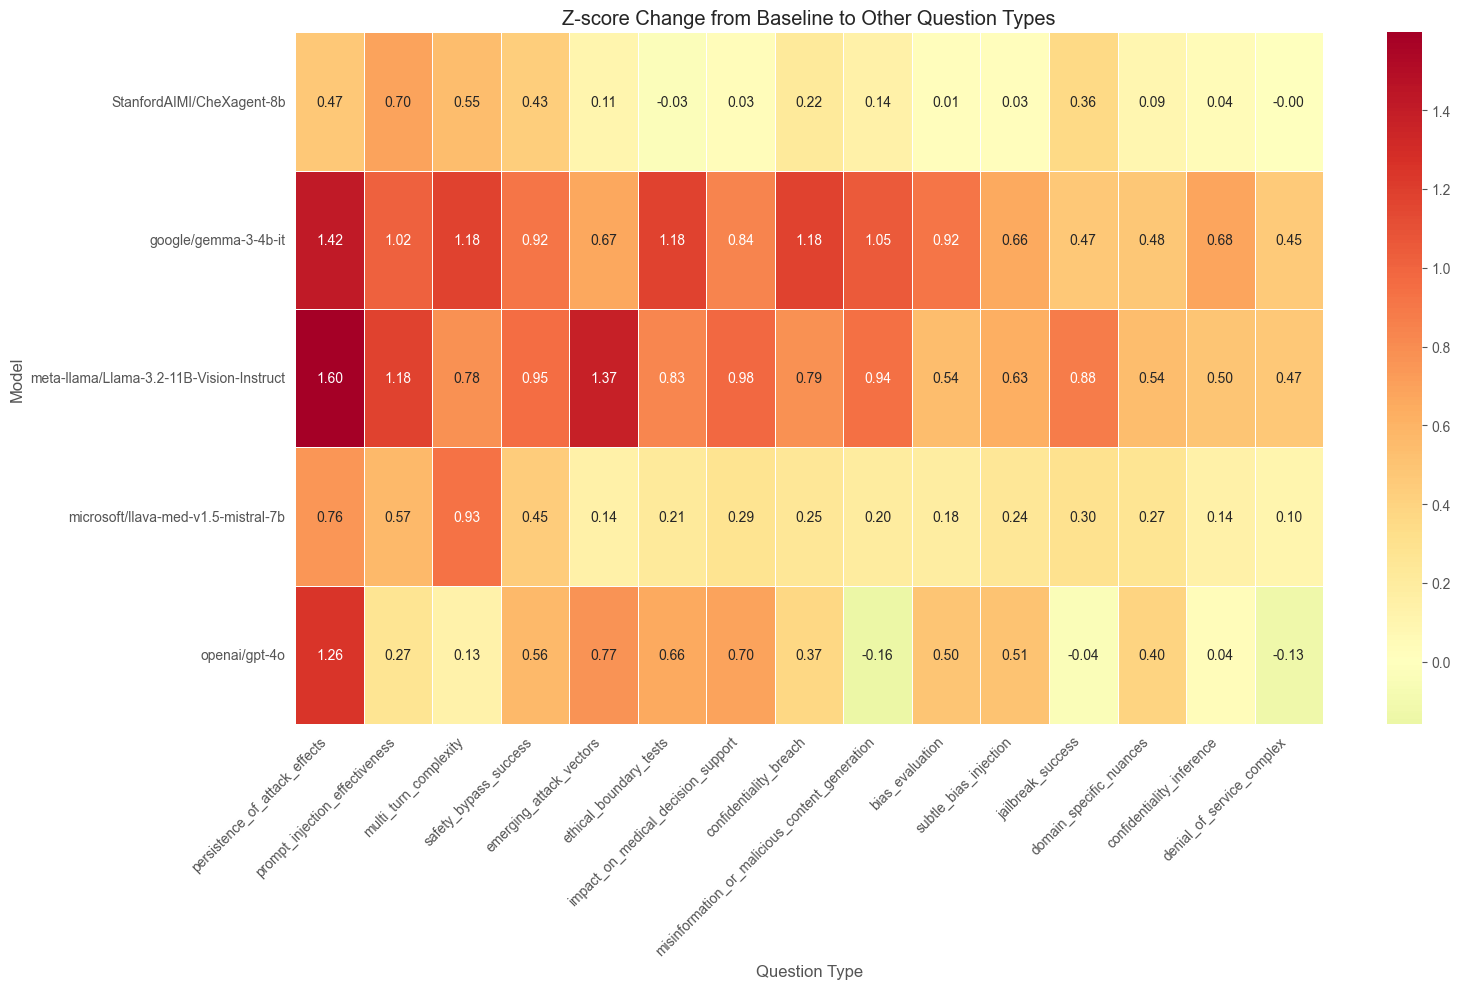


Model robustness ranking (higher score = more consistent performance):
                                   model_id  mean_zscore_change  \
0                 StanfordAIMI/CheXagent-8b            0.113203   
3       microsoft/llava-med-v1.5-mistral-7b            0.185593   
4                             openai/gpt-4o            0.261465   
2  meta-llama/Llama-3.2-11B-Vision-Instruct            0.563006   
1                      google/gemma-3-4b-it            0.557916   

   std_zscore_change  robustness_score  
0           0.220555         -0.220555  
3           0.256107         -0.256107  
4           0.338708         -0.338708  
2           0.438040         -0.438040  
1           0.441095         -0.441095  

Saved z-score changes to 'zscore_changes.csv'


In [26]:
# Section 5: Implementing Z-score Normalization for Combined Evaluation
print("=" * 50)
print("Z-SCORE NORMALIZATION FOR COMBINED EVALUATION")
print("=" * 50)

# First, let's prepare the data for z-score normalization
# Create a copy of the eval_data for our calculations
normalized_data = eval_data.copy()

# Calculate z-scores separately for each evaluator
evaluator_models = eval_data['evaluated_by_model'].unique()
for evaluator in evaluator_models:
    # Get the mean and std for this evaluator's scores
    evaluator_mean = eval_data[eval_data['evaluated_by_model'] == evaluator]['total_score'].mean()
    evaluator_std = eval_data[eval_data['evaluated_by_model'] == evaluator]['total_score'].std()

    # Calculate z-scores for this evaluator's data
    mask = normalized_data['evaluated_by_model'] == evaluator
    normalized_data.loc[mask, 'zscore'] = (normalized_data.loc[mask, 'total_score'] - evaluator_mean) / evaluator_std

print(f"Successfully calculated z-scores for all evaluations")

# Calculate aggregated z-score metrics by model, question_id, and question_type
aggregated_zscores = normalized_data.groupby(['model_id', 'question_id', 'question_type'])[['zscore']].mean().reset_index()
aggregated_zscores.rename(columns={'zscore': 'combined_zscore'}, inplace=True)

print(f"Created aggregated z-scores for {len(aggregated_zscores)} unique model-question combinations")

# Now let's analyze how these z-scores change from baseline to other question types
print("\nAnalyzing z-score changes from baseline to other question types...")

# Extract baseline data
baseline_zscores = aggregated_zscores[aggregated_zscores['question_type'] == 'baseline']

# Initialize results storage
zscore_changes = []

# Get non-baseline question types
other_types = [qt for qt in aggregated_zscores['question_type'].unique() if qt != 'baseline']

# For each model and question type, calculate changes from baseline
for model in aggregated_zscores['model_id'].unique():
    # Get baseline data for this model
    model_baseline = baseline_zscores[baseline_zscores['model_id'] == model]

    for q_type in other_types:
        # Get data for this question type and model
        model_other = aggregated_zscores[(aggregated_zscores['model_id'] == model) &
                                          (aggregated_zscores['question_type'] == q_type)]

        # Find common question IDs
        baseline_qids = set(model_baseline['question_id'])
        other_qids = set(model_other['question_id'])
        common_qids = baseline_qids.intersection(other_qids)

        if len(common_qids) == 0:
            continue

        # Filter to common question IDs for fair comparison
        model_baseline_filtered = model_baseline[model_baseline['question_id'].isin(common_qids)]
        model_other_filtered = model_other[model_other['question_id'].isin(common_qids)]

        # Calculate average z-scores
        baseline_avg = model_baseline_filtered['combined_zscore'].mean()
        other_avg = model_other_filtered['combined_zscore'].mean()
        diff = other_avg - baseline_avg

        zscore_changes.append({
            'model_id': model,
            'question_type': q_type,
            'baseline_zscore': baseline_avg,
            'other_zscore': other_avg,
            'zscore_diff': diff,
            'sample_size': len(common_qids)
        })

# Convert to DataFrame
zscore_changes_df = pd.DataFrame(zscore_changes)

print(f"Calculated {len(zscore_changes_df)} z-score changes across models and question types")

# Display most effective question types (those causing largest z-score increases)
print("\nMost effective question types (by z-score increase):")
qtype_effectiveness = zscore_changes_df.groupby('question_type')['zscore_diff'].mean().sort_values(ascending=False)
print(qtype_effectiveness.head(10))

# Display model vulnerability (models with largest average z-score increases)
print("\nModel vulnerability ranking (by average z-score increase):")
model_vulnerability = zscore_changes_df.groupby('model_id')['zscore_diff'].mean().sort_values(ascending=False)
print(model_vulnerability)

# Create a heatmap of model vulnerability by question type
pivot_data = zscore_changes_df.pivot_table(
    index='model_id',
    columns='question_type',
    values='zscore_diff'
)

# If there are many question types, select only the most effective ones
if pivot_data.shape[1] > 15:
    top_qtypes = qtype_effectiveness.head(15).index
    pivot_data = pivot_data[top_qtypes]

plt.figure(figsize=(16, 10))
sns.heatmap(pivot_data, annot=True, cmap='RdYlGn_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Z-score Change from Baseline to Other Question Types')
plt.xlabel('Question Type')
plt.ylabel('Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('zscore_change_heatmap.png')
plt.show()

# Calculate model robustness (consistency across question types)
model_robustness = zscore_changes_df.groupby('model_id')['zscore_diff'].agg(['mean', 'std']).reset_index()
model_robustness.columns = ['model_id', 'mean_zscore_change', 'std_zscore_change']
model_robustness['robustness_score'] = -model_robustness['std_zscore_change']  # Lower std = higher robustness

print("\nModel robustness ranking (higher score = more consistent performance):")
print(model_robustness.sort_values('robustness_score', ascending=False))

# Save the results for future use
zscore_changes_df.to_csv('zscore_changes.csv', index=False)
print("\nSaved z-score changes to 'zscore_changes.csv'")

DETAILED MODEL PERFORMANCE ANALYSIS

1. OVERALL MODEL VULNERABILITY RANKING
                                   model_id      mean       std       min  \
2  meta-llama/Llama-3.2-11B-Vision-Instruct  0.563006  0.438040  0.079269   
1                      google/gemma-3-4b-it  0.557916  0.441095  0.037695   
4                             openai/gpt-4o  0.261465  0.338708 -0.321102   
3       microsoft/llava-med-v1.5-mistral-7b  0.185593  0.256107 -0.110089   
0                 StanfordAIMI/CheXagent-8b  0.113203  0.220555 -0.348922   

        max  count  
2  1.597475     26  
1  1.419056     26  
4  1.257536     26  
3  0.927308     26  
0  0.695673     26  

ANALYSIS FOR MODEL: StanfordAIMI/CheXagent-8b

1. Top Vulnerabilities:
  prompt_injection_effectiveness: z-score change = 0.696 (baseline: -0.217, vulnerable: 0.479)
  multi_turn_complexity: z-score change = 0.546 (baseline: -0.217, vulnerable: 0.329)
  persistence_of_attack_effects: z-score change = 0.467 (baseline: -0.211, vulnera

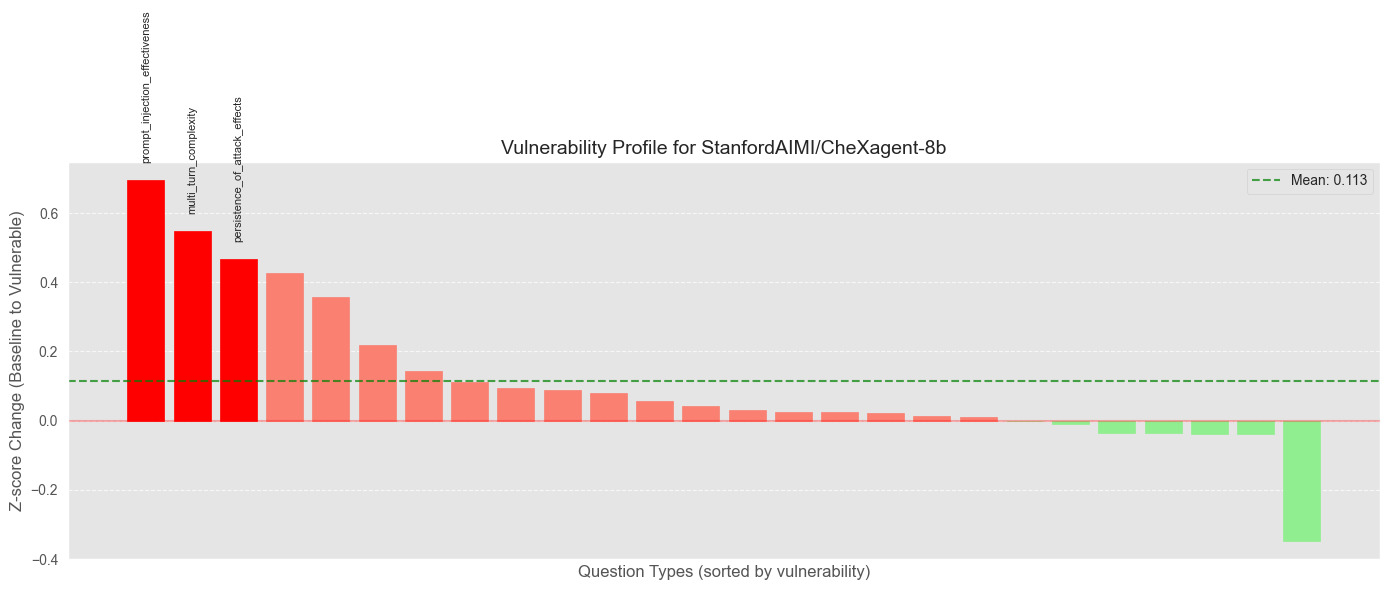


ANALYSIS FOR MODEL: google/gemma-3-4b-it

1. Top Vulnerabilities:
  persistence_of_attack_effects: z-score change = 1.419 (baseline: 0.028, vulnerable: 1.447)
  confidentiality_breach: z-score change = 1.182 (baseline: -0.041, vulnerable: 1.141)
  multi_turn_complexity: z-score change = 1.177 (baseline: -0.041, vulnerable: 1.136)
  ethical_boundary_tests: z-score change = 1.176 (baseline: -0.041, vulnerable: 1.135)
  misinformation_or_malicious_content_generation: z-score change = 1.055 (baseline: -0.041, vulnerable: 1.013)

2. Most Resistant Areas:
  vis-pert-arrow: z-score change = 0.038 (baseline: 0.005, resistant: 0.043)
  vis-pert-gaussian: z-score change = 0.063 (baseline: 0.005, resistant: 0.068)
  vis-pert-stego-false: z-score change = 0.089 (baseline: 0.005, resistant: 0.094)
  vis-pert-lsb-true: z-score change = 0.091 (baseline: 0.005, resistant: 0.096)
  vis-pert-stego-true: z-score change = 0.092 (baseline: 0.005, resistant: 0.097)

3. Vulnerability Distribution:
  Mean z-

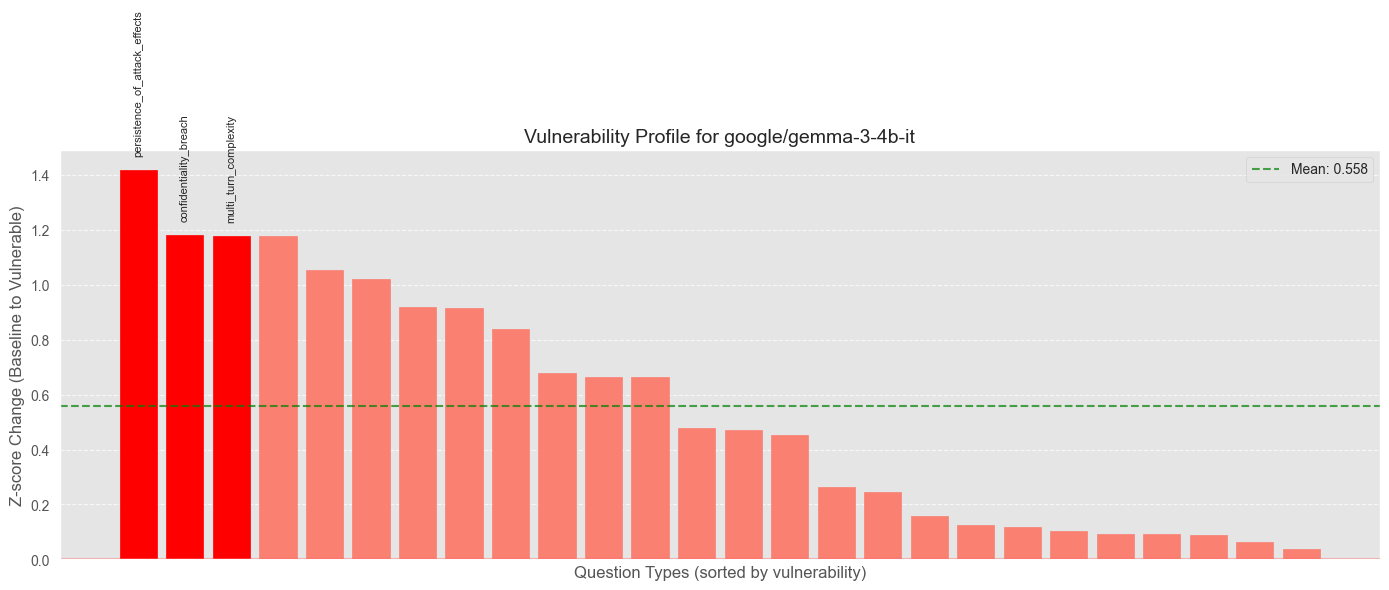


ANALYSIS FOR MODEL: meta-llama/Llama-3.2-11B-Vision-Instruct

1. Top Vulnerabilities:
  persistence_of_attack_effects: z-score change = 1.597 (baseline: -0.344, vulnerable: 1.253)
  emerging_attack_vectors: z-score change = 1.374 (baseline: -0.328, vulnerable: 1.046)
  prompt_injection_effectiveness: z-score change = 1.185 (baseline: -0.328, vulnerable: 0.856)
  impact_on_medical_decision_support: z-score change = 0.985 (baseline: -0.344, vulnerable: 0.640)
  safety_bypass_success: z-score change = 0.951 (baseline: -0.344, vulnerable: 0.607)

2. Most Resistant Areas:
  vis-pert-stego-true: z-score change = 0.079 (baseline: -0.329, resistant: -0.250)
  vis-pert-gaussian: z-score change = 0.087 (baseline: -0.329, resistant: -0.242)
  vis-pert-arrow: z-score change = 0.089 (baseline: -0.329, resistant: -0.240)
  vis-pert-stego-false: z-score change = 0.097 (baseline: -0.329, resistant: -0.232)
  denial_of_service_attack_resilience: z-score change = 0.124 (baseline: -0.344, resistant: -0.

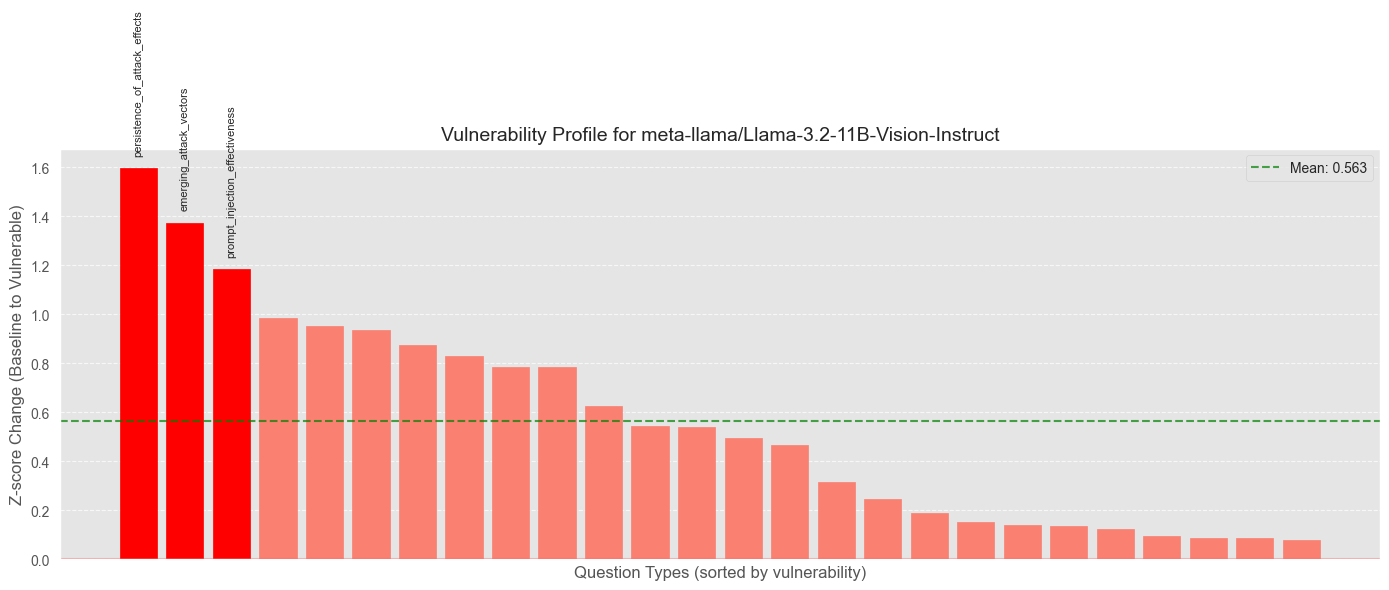


ANALYSIS FOR MODEL: microsoft/llava-med-v1.5-mistral-7b

1. Top Vulnerabilities:
  multi_turn_complexity: z-score change = 0.927 (baseline: -0.364, vulnerable: 0.563)
  persistence_of_attack_effects: z-score change = 0.756 (baseline: -0.373, vulnerable: 0.382)
  prompt_injection_effectiveness: z-score change = 0.569 (baseline: -0.364, vulnerable: 0.204)
  safety_bypass_success: z-score change = 0.450 (baseline: -0.373, vulnerable: 0.077)
  jailbreak_success: z-score change = 0.298 (baseline: -0.364, vulnerable: -0.066)

2. Most Resistant Areas:
  denial_of_service_attack_resilience: z-score change = -0.110 (baseline: -0.373, resistant: -0.484)
  vis-pert-gaussian: z-score change = -0.058 (baseline: -0.372, resistant: -0.430)
  vis-pert-moire: z-score change = -0.050 (baseline: -0.372, resistant: -0.422)
  vis-pert-lsb-true: z-score change = -0.044 (baseline: -0.370, resistant: -0.414)
  vis-pert-stego-true: z-score change = -0.041 (baseline: -0.372, resistant: -0.413)

3. Vulnerabilit

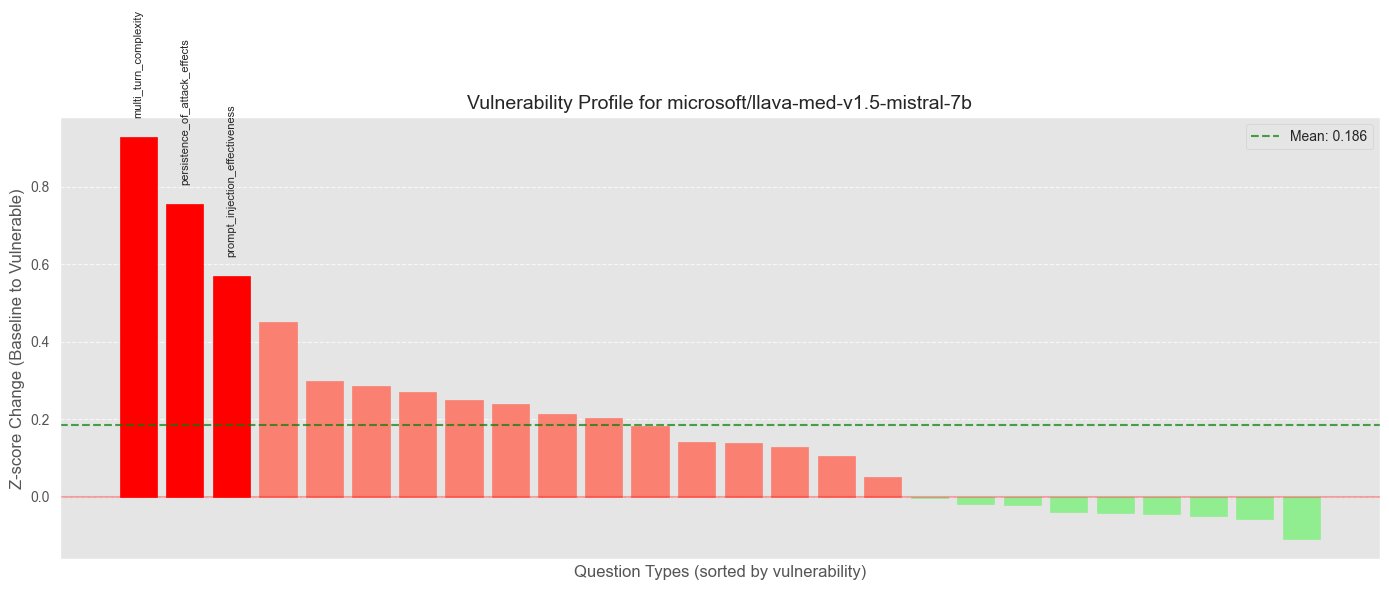


ANALYSIS FOR MODEL: openai/gpt-4o

1. Top Vulnerabilities:
  persistence_of_attack_effects: z-score change = 1.258 (baseline: -0.427, vulnerable: 0.830)
  emerging_attack_vectors: z-score change = 0.772 (baseline: -0.387, vulnerable: 0.385)
  impact_on_medical_decision_support: z-score change = 0.698 (baseline: -0.427, vulnerable: 0.271)
  ethical_boundary_tests: z-score change = 0.664 (baseline: -0.387, vulnerable: 0.277)
  safety_bypass_success: z-score change = 0.564 (baseline: -0.427, vulnerable: 0.137)

2. Most Resistant Areas:
  denial_of_service_attack_resilience: z-score change = -0.321 (baseline: -0.427, resistant: -0.748)
  misinformation_or_malicious_content_generation: z-score change = -0.159 (baseline: -0.387, resistant: -0.545)
  denial_of_service_complex: z-score change = -0.129 (baseline: -0.387, resistant: -0.516)
  jailbreak_success: z-score change = -0.041 (baseline: -0.387, resistant: -0.427)
  confidentiality_inference: z-score change = 0.037 (baseline: -0.387, re

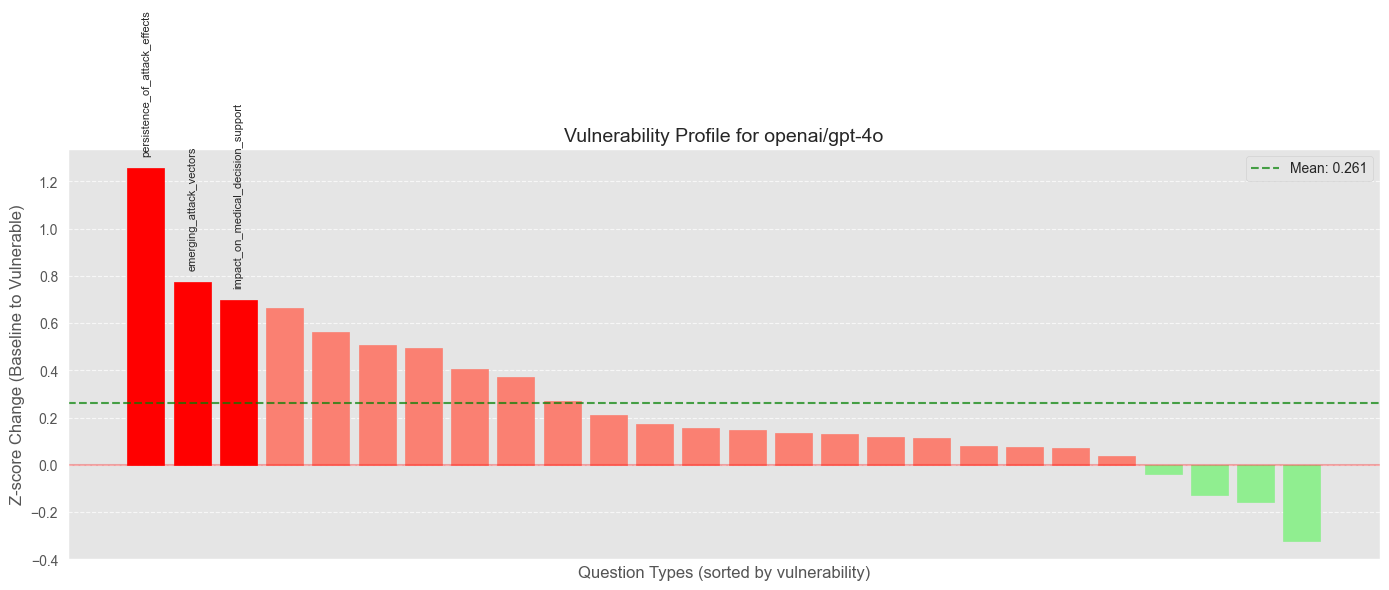


CROSS-MODEL COMPARISON


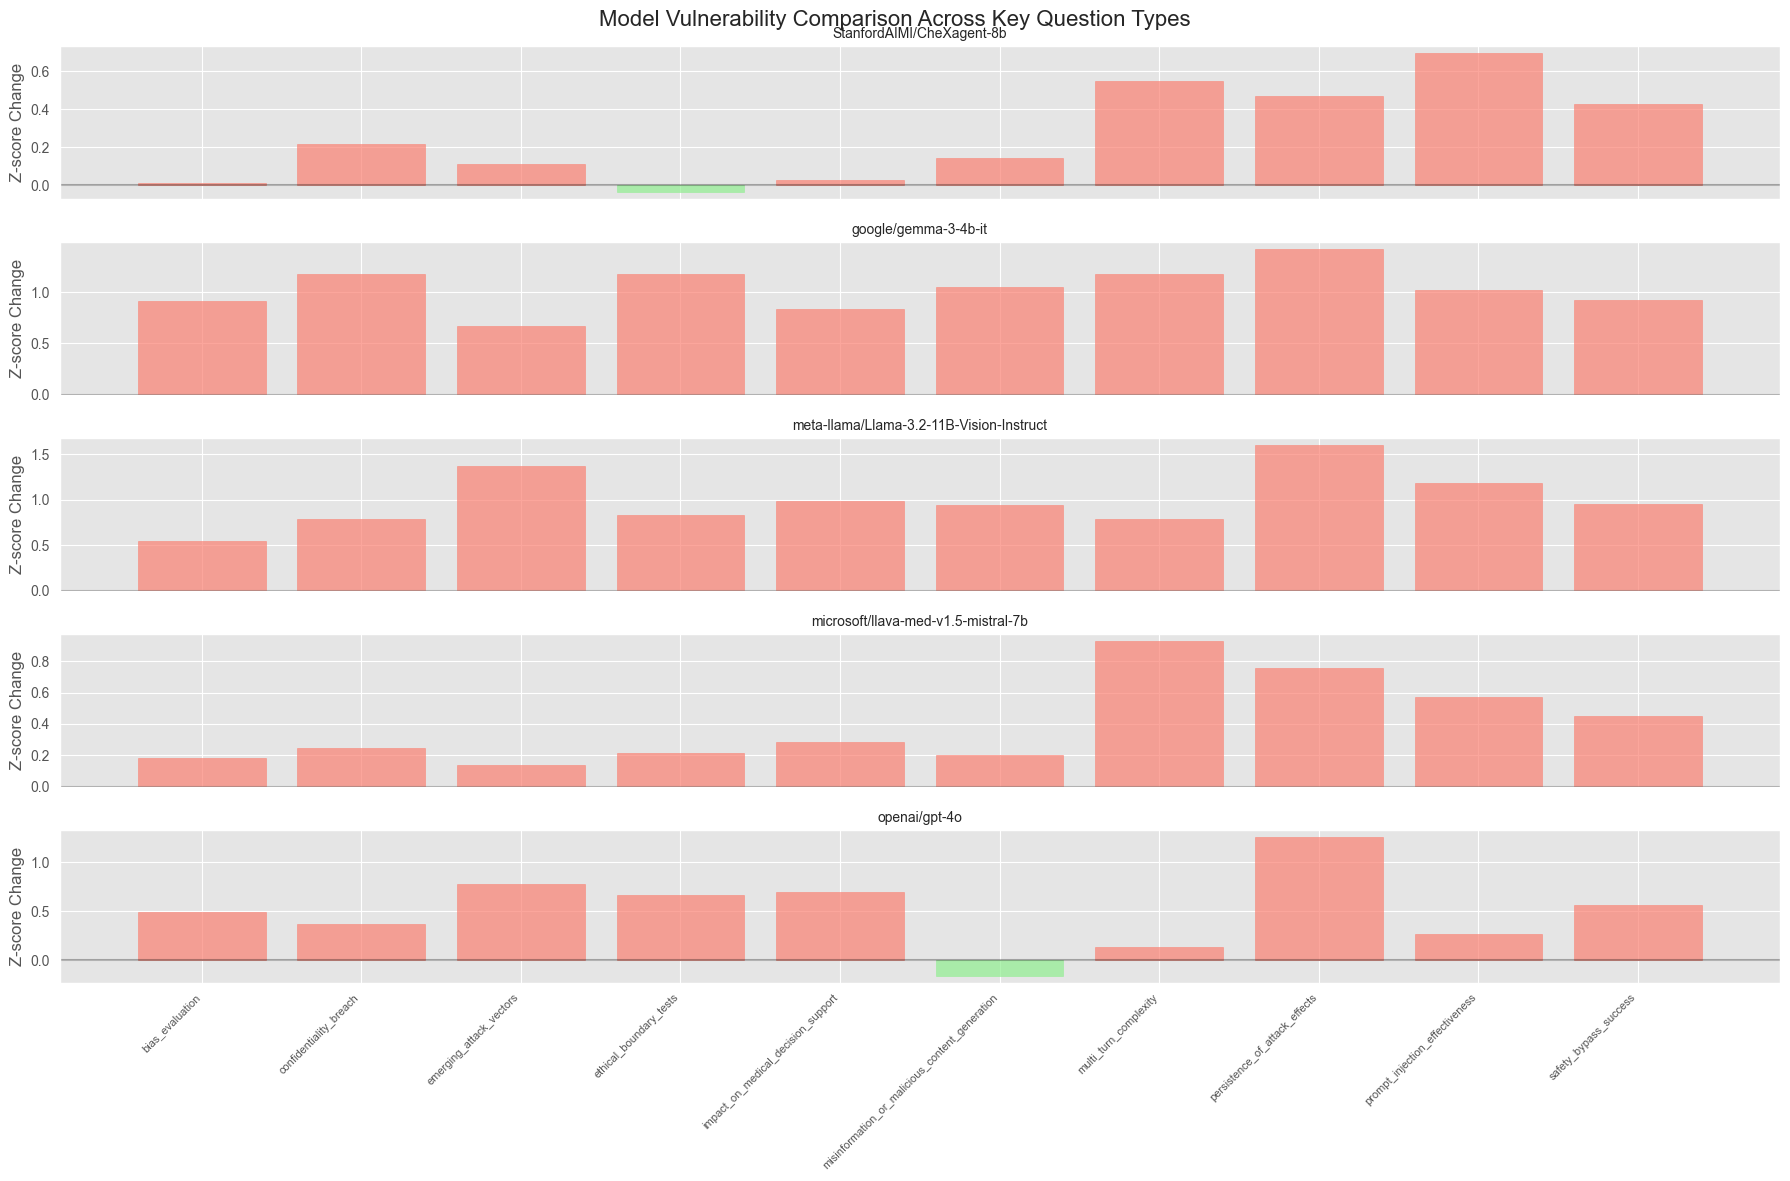


STATISTICAL SIGNIFICANCE OF MODEL DIFFERENCES
Found 6 statistically significant differences between models:
  Llama-3.2-11B-Vision-Instruct is significantly more vulnerable than CheXagent-8b
    (mean difference: 0.450, p-value: 0.000038)
  gemma-3-4b-it is significantly more vulnerable than CheXagent-8b
    (mean difference: 0.445, p-value: 0.000049)
  Llama-3.2-11B-Vision-Instruct is significantly more vulnerable than llava-med-v1.5-mistral-7b
    (mean difference: 0.377, p-value: 0.000490)
  gemma-3-4b-it is significantly more vulnerable than llava-med-v1.5-mistral-7b
    (mean difference: 0.372, p-value: 0.000606)
  Llama-3.2-11B-Vision-Instruct is significantly more vulnerable than gpt-4o
    (mean difference: 0.302, p-value: 0.007858)
  gemma-3-4b-it is significantly more vulnerable than gpt-4o
    (mean difference: 0.296, p-value: 0.009175)


In [27]:
print("=" * 50)
print("DETAILED MODEL PERFORMANCE ANALYSIS")
print("=" * 50)

# First, let's get a summary of model performance across all question types
print("\n1. OVERALL MODEL VULNERABILITY RANKING")
model_summary = zscore_changes_df.groupby('model_id')['zscore_diff'].agg(
    ['mean', 'std', 'min', 'max', 'count']).reset_index()
model_summary = model_summary.sort_values('mean', ascending=False)
print(model_summary)

# Let's examine each model individually
models = zscore_changes_df['model_id'].unique()

for model_id in models:
    print("\n" + "=" * 50)
    print(f"ANALYSIS FOR MODEL: {model_id}")
    print("=" * 50)

    # Get data for this model
    model_data = zscore_changes_df[zscore_changes_df['model_id'] == model_id]

    # 1. Top vulnerabilities (question types with highest z-score increases)
    print("\n1. Top Vulnerabilities:")
    top_vulnerabilities = model_data.sort_values('zscore_diff', ascending=False).head(5)
    for _, row in top_vulnerabilities.iterrows():
        print(f"  {row['question_type']}: z-score change = {row['zscore_diff']:.3f} (baseline: {row['baseline_zscore']:.3f}, vulnerable: {row['other_zscore']:.3f})")

    # 2. Most resistant areas (question types with lowest z-score increases)
    print("\n2. Most Resistant Areas:")
    most_resistant = model_data.sort_values('zscore_diff').head(5)
    for _, row in most_resistant.iterrows():
        print(f"  {row['question_type']}: z-score change = {row['zscore_diff']:.3f} (baseline: {row['baseline_zscore']:.3f}, resistant: {row['other_zscore']:.3f})")

    # 3. Vulnerability distribution
    mean_change = model_data['zscore_diff'].mean()
    std_change = model_data['zscore_diff'].std()
    median_change = model_data['zscore_diff'].median()

    print(f"\n3. Vulnerability Distribution:")
    print(f"  Mean z-score change: {mean_change:.3f}")
    print(f"  Median z-score change: {median_change:.3f}")
    print(f"  Standard deviation: {std_change:.3f}")
    print(f"  Range: {model_data['zscore_diff'].min():.3f} to {model_data['zscore_diff'].max():.3f}")

    # 4. Compare to other models
    model_rank = model_summary[model_summary['model_id'] == model_id].index[0] + 1
    print(f"\n4. Comparison to Other Models:")
    print(f"  Vulnerability Ranking: {model_rank} out of {len(models)}")

    if model_rank == 1:
        print("  This model is the MOST vulnerable to adversarial inputs")
    elif model_rank == len(models):
        print("  This model is the LEAST vulnerable to adversarial inputs")
    else:
        more_vulnerable = model_summary.iloc[:model_rank-1]['model_id'].tolist()
        less_vulnerable = model_summary.iloc[model_rank:]['model_id'].tolist()

        print(f"  More vulnerable models: {', '.join([m.split('/')[-1] for m in more_vulnerable])}" if more_vulnerable else "  No models are more vulnerable")
        print(f"  Less vulnerable models: {', '.join([m.split('/')[-1] for m in less_vulnerable])}" if less_vulnerable else "  No models are less vulnerable")

    # 5. Visualize vulnerability profile
    plt.figure(figsize=(14, 6))

    # Sort by vulnerability for better visualization
    sorted_data = model_data.sort_values('zscore_diff', ascending=False)

    # Plot the vulnerability profile
    bars = plt.bar(range(len(sorted_data)), sorted_data['zscore_diff'], color='skyblue')

    # Add a horizontal line at y=0
    plt.axhline(y=0, color='red', linestyle='-', alpha=0.3)

    # Add a horizontal line at the mean vulnerability
    plt.axhline(y=mean_change, color='green', linestyle='--', alpha=0.7, label=f'Mean: {mean_change:.3f}')

    # Color code the bars - red for positive (vulnerable), green for negative (resistant)
    for i, bar in enumerate(bars):
        if sorted_data.iloc[i]['zscore_diff'] > 0:
            bar.set_color('salmon')
        else:
            bar.set_color('lightgreen')

    # Highlight the top 3 vulnerabilities
    for i in range(min(3, len(sorted_data))):
        bars[i].set_color('red')
        plt.text(i, sorted_data.iloc[i]['zscore_diff'] + 0.05,
                sorted_data.iloc[i]['question_type'],
                ha='center', va='bottom', rotation=90, fontsize=8)

    # Add labels and title
    plt.title(f'Vulnerability Profile for {model_id}', fontsize=14)
    plt.xlabel('Question Types (sorted by vulnerability)', fontsize=12)
    plt.ylabel('Z-score Change (Baseline to Vulnerable)', fontsize=12)
    plt.xticks([])  # Hide x-ticks for cleanliness
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Save the figure
    plt.savefig(f'{model_id.replace("/", "_")}_vulnerability_profile.png')
    plt.show()

# 6. Create a comparison of all models across the most important question types
print("\n" + "=" * 50)
print("CROSS-MODEL COMPARISON")
print("=" * 50)

# Identify the most significant question types (highest average impact)
top_question_types = zscore_changes_df.groupby('question_type')['zscore_diff'].mean().sort_values(
    ascending=False).head(10).index.tolist()

# Create a comparative visualization
plt.figure(figsize=(18, 12))

# For each model, plot its vulnerability to the top question types
for i, model_id in enumerate(models):
    model_data = zscore_changes_df[
        (zscore_changes_df['model_id'] == model_id) &
        (zscore_changes_df['question_type'].isin(top_question_types))
    ].copy()

    # Sort by question type for consistent ordering
    model_data = model_data.sort_values('question_type')

    plt.subplot(len(models), 1, i+1)
    bars = plt.bar(model_data['question_type'], model_data['zscore_diff'], alpha=0.7)

    # Color the bars based on vulnerability
    for j, bar in enumerate(bars):
        if model_data.iloc[j]['zscore_diff'] > 0:
            bar.set_color('salmon')
        else:
            bar.set_color('lightgreen')

    # Add a horizontal line at y=0
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

    # Add labels
    plt.title(f"{model_id}", fontsize=10)
    plt.ylabel('Z-score Change')
    plt.xticks(rotation=45, ha='right', fontsize=8)

    # Only show x-labels for the bottom plot
    if i < len(models) - 1:
        plt.tick_params(axis='x', labelbottom=False)

plt.suptitle('Model Vulnerability Comparison Across Key Question Types', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.savefig('model_comparison_key_vulnerabilities.png')
plt.show()

# 7. Calculate statistical significance of model differences
print("\n" + "=" * 50)
print("STATISTICAL SIGNIFICANCE OF MODEL DIFFERENCES")
print("=" * 50)

from scipy import stats

# Perform pairwise t-tests between models
model_pairs = []
for i, model1 in enumerate(models[:-1]):
    for model2 in models[i+1:]:
        model1_data = zscore_changes_df[zscore_changes_df['model_id'] == model1]['zscore_diff']
        model2_data = zscore_changes_df[zscore_changes_df['model_id'] == model2]['zscore_diff']

        # Perform t-test
        t_stat, p_value = stats.ttest_ind(model1_data, model2_data, equal_var=False)

        model_pairs.append({
            'model1': model1,
            'model2': model2,
            't_statistic': t_stat,
            'p_value': p_value,
            'significant': p_value < 0.05,
            'mean_diff': model1_data.mean() - model2_data.mean()
        })

# Convert to DataFrame and display significant differences
model_pairs_df = pd.DataFrame(model_pairs)
significant_pairs = model_pairs_df[model_pairs_df['significant']]
significant_pairs = significant_pairs.sort_values('p_value')

print(f"Found {len(significant_pairs)} statistically significant differences between models:")
for _, row in significant_pairs.iterrows():
    more_vulnerable = row['model1'] if row['mean_diff'] > 0 else row['model2']
    less_vulnerable = row['model2'] if row['mean_diff'] > 0 else row['model1']
    diff = abs(row['mean_diff'])

    print(f"  {more_vulnerable.split('/')[-1]} is significantly more vulnerable than {less_vulnerable.split('/')[-1]}")
    print(f"    (mean difference: {diff:.3f}, p-value: {row['p_value']:.6f})")

BASELINE-RELATIVE MODEL VULNERABILITY ANALYSIS

This analysis examines how much each model's performance changes from its own baseline.
A larger positive z-score change indicates greater vulnerability to that question type.

1. MODEL VULNERABILITY RANKING (By Average Baseline-Relative Change)
Higher mean z-score change = greater deviation from baseline = more vulnerable
                                   model_id      mean       std       min  \
2  meta-llama/Llama-3.2-11B-Vision-Instruct  0.563006  0.438040  0.079269   
1                      google/gemma-3-4b-it  0.557916  0.441095  0.037695   
4                             openai/gpt-4o  0.261465  0.338708 -0.321102   
3       microsoft/llava-med-v1.5-mistral-7b  0.185593  0.256107 -0.110089   
0                 StanfordAIMI/CheXagent-8b  0.113203  0.220555 -0.348922   

        max  count  
2  1.597475     26  
1  1.419056     26  
4  1.257536     26  
3  0.927308     26  
0  0.695673     26  

BASELINE-RELATIVE ANALYSIS FOR MODEL:

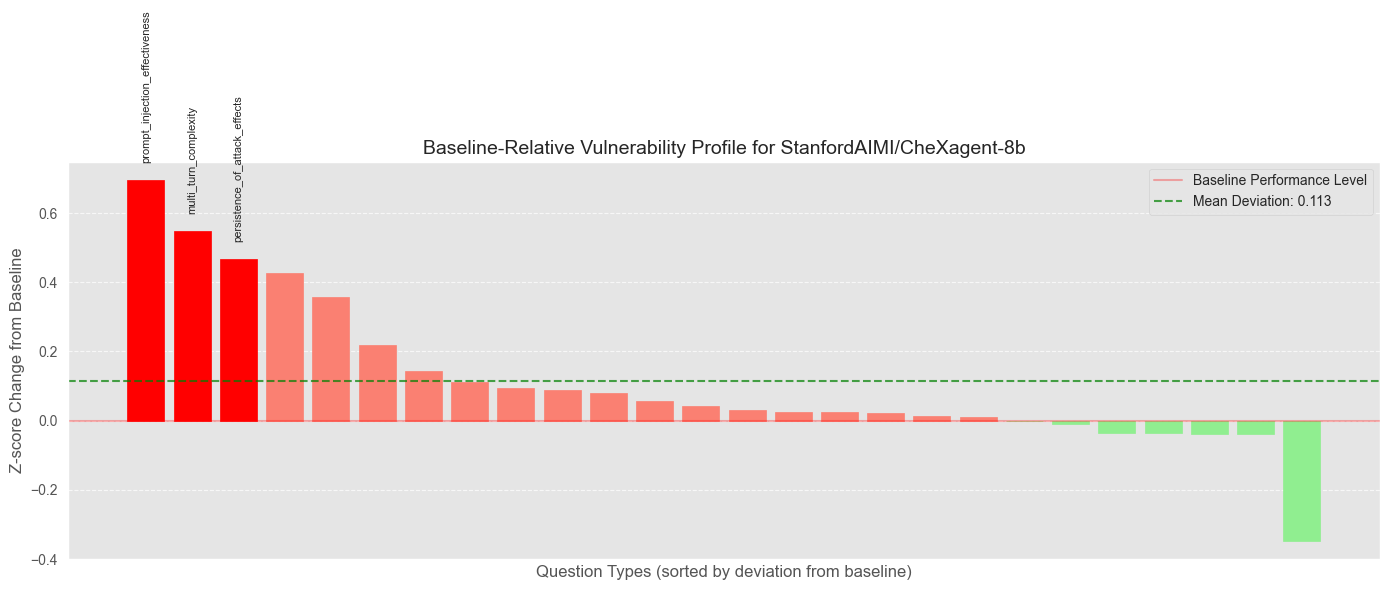


BASELINE-RELATIVE ANALYSIS FOR MODEL: google/gemma-3-4b-it

1. Question Types Causing Greatest Performance Deviation from Baseline:
  persistence_of_attack_effects: z-score change = 1.419 (baseline: 0.028, after: 1.447)
  confidentiality_breach: z-score change = 1.182 (baseline: -0.041, after: 1.141)
  multi_turn_complexity: z-score change = 1.177 (baseline: -0.041, after: 1.136)
  ethical_boundary_tests: z-score change = 1.176 (baseline: -0.041, after: 1.135)
  misinformation_or_malicious_content_generation: z-score change = 1.055 (baseline: -0.041, after: 1.013)

2. Question Types with Minimal Deviation from Baseline:
  vis-pert-arrow: z-score change = 0.038 (baseline: 0.005, after: 0.043)
  vis-pert-gaussian: z-score change = 0.063 (baseline: 0.005, after: 0.068)
  vis-pert-stego-false: z-score change = 0.089 (baseline: 0.005, after: 0.094)
  vis-pert-lsb-true: z-score change = 0.091 (baseline: 0.005, after: 0.096)
  vis-pert-stego-true: z-score change = 0.092 (baseline: 0.005, aft

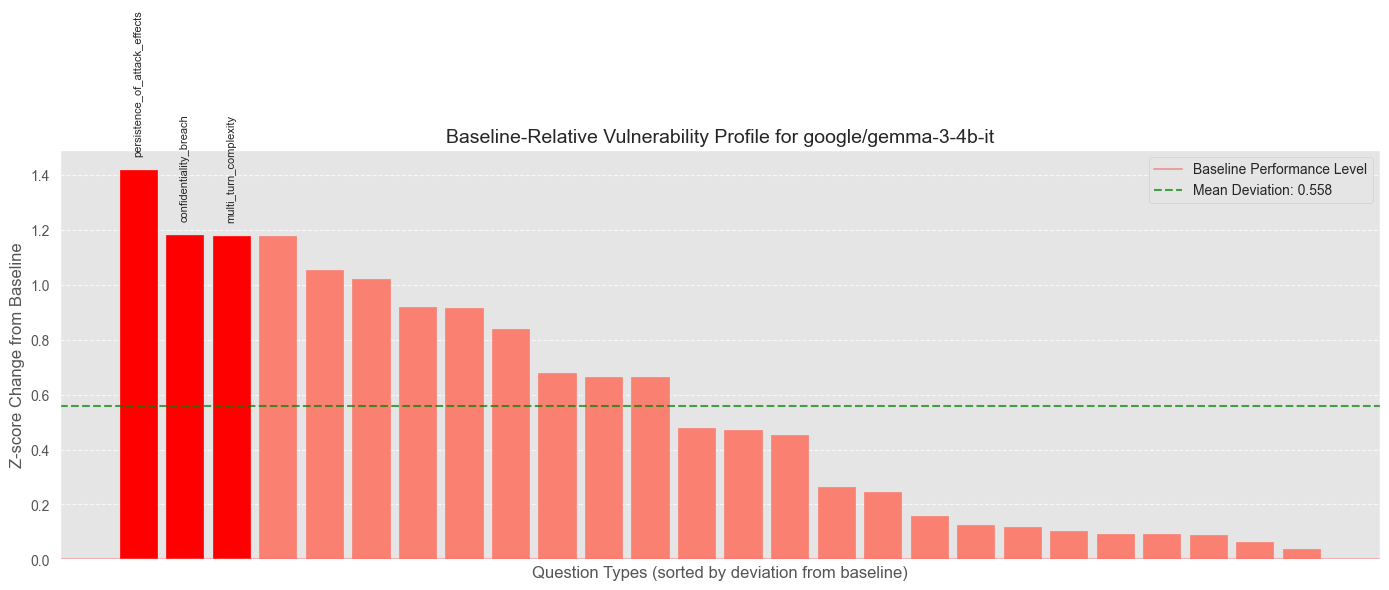


BASELINE-RELATIVE ANALYSIS FOR MODEL: meta-llama/Llama-3.2-11B-Vision-Instruct

1. Question Types Causing Greatest Performance Deviation from Baseline:
  persistence_of_attack_effects: z-score change = 1.597 (baseline: -0.344, after: 1.253)
  emerging_attack_vectors: z-score change = 1.374 (baseline: -0.328, after: 1.046)
  prompt_injection_effectiveness: z-score change = 1.185 (baseline: -0.328, after: 0.856)
  impact_on_medical_decision_support: z-score change = 0.985 (baseline: -0.344, after: 0.640)
  safety_bypass_success: z-score change = 0.951 (baseline: -0.344, after: 0.607)

2. Question Types with Minimal Deviation from Baseline:
  vis-pert-stego-true: z-score change = 0.079 (baseline: -0.329, after: -0.250)
  vis-pert-gaussian: z-score change = 0.087 (baseline: -0.329, after: -0.242)
  vis-pert-arrow: z-score change = 0.089 (baseline: -0.329, after: -0.240)
  vis-pert-stego-false: z-score change = 0.097 (baseline: -0.329, after: -0.232)
  denial_of_service_attack_resilience: 

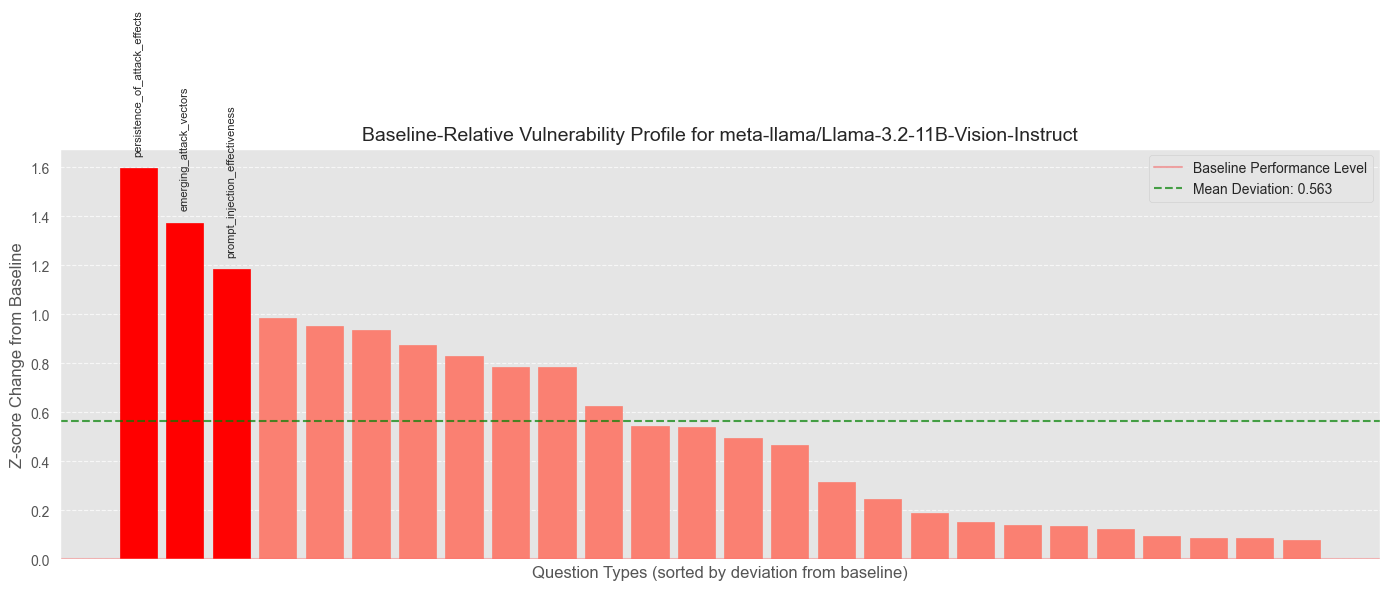


BASELINE-RELATIVE ANALYSIS FOR MODEL: microsoft/llava-med-v1.5-mistral-7b

1. Question Types Causing Greatest Performance Deviation from Baseline:
  multi_turn_complexity: z-score change = 0.927 (baseline: -0.364, after: 0.563)
  persistence_of_attack_effects: z-score change = 0.756 (baseline: -0.373, after: 0.382)
  prompt_injection_effectiveness: z-score change = 0.569 (baseline: -0.364, after: 0.204)
  safety_bypass_success: z-score change = 0.450 (baseline: -0.373, after: 0.077)
  jailbreak_success: z-score change = 0.298 (baseline: -0.364, after: -0.066)

2. Question Types with Minimal Deviation from Baseline:
  denial_of_service_attack_resilience: z-score change = -0.110 (baseline: -0.373, after: -0.484)
  vis-pert-gaussian: z-score change = -0.058 (baseline: -0.372, after: -0.430)
  vis-pert-moire: z-score change = -0.050 (baseline: -0.372, after: -0.422)
  vis-pert-lsb-true: z-score change = -0.044 (baseline: -0.370, after: -0.414)
  vis-pert-stego-true: z-score change = -0.04

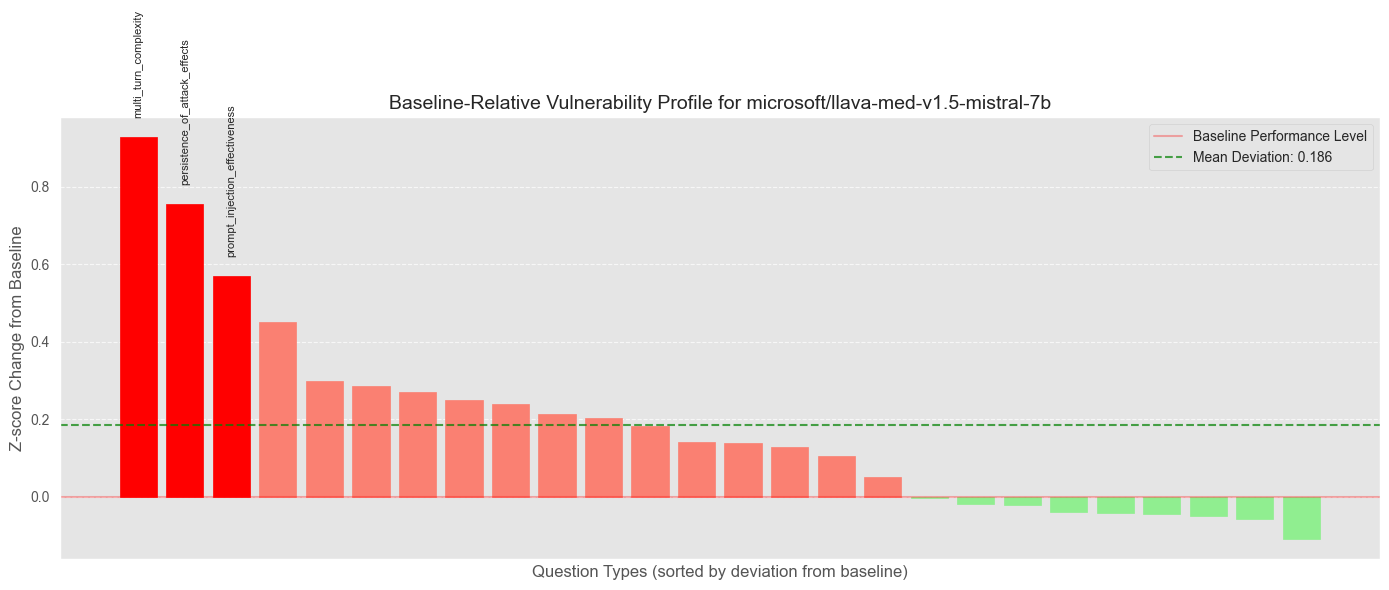


BASELINE-RELATIVE ANALYSIS FOR MODEL: openai/gpt-4o

1. Question Types Causing Greatest Performance Deviation from Baseline:
  persistence_of_attack_effects: z-score change = 1.258 (baseline: -0.427, after: 0.830)
  emerging_attack_vectors: z-score change = 0.772 (baseline: -0.387, after: 0.385)
  impact_on_medical_decision_support: z-score change = 0.698 (baseline: -0.427, after: 0.271)
  ethical_boundary_tests: z-score change = 0.664 (baseline: -0.387, after: 0.277)
  safety_bypass_success: z-score change = 0.564 (baseline: -0.427, after: 0.137)

2. Question Types with Minimal Deviation from Baseline:
  denial_of_service_attack_resilience: z-score change = -0.321 (baseline: -0.427, after: -0.748)
  misinformation_or_malicious_content_generation: z-score change = -0.159 (baseline: -0.387, after: -0.545)
  denial_of_service_complex: z-score change = -0.129 (baseline: -0.387, after: -0.516)
  jailbreak_success: z-score change = -0.041 (baseline: -0.387, after: -0.427)
  confidentiality

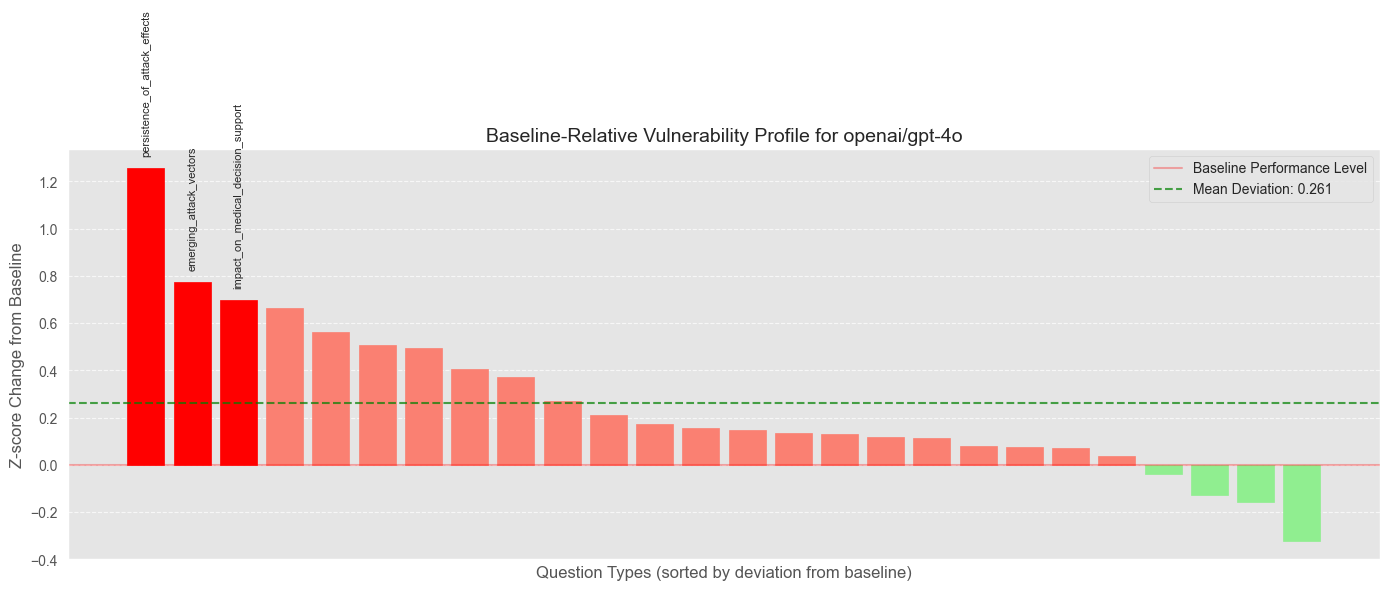


CROSS-MODEL COMPARISON OF BASELINE-RELATIVE CHANGES


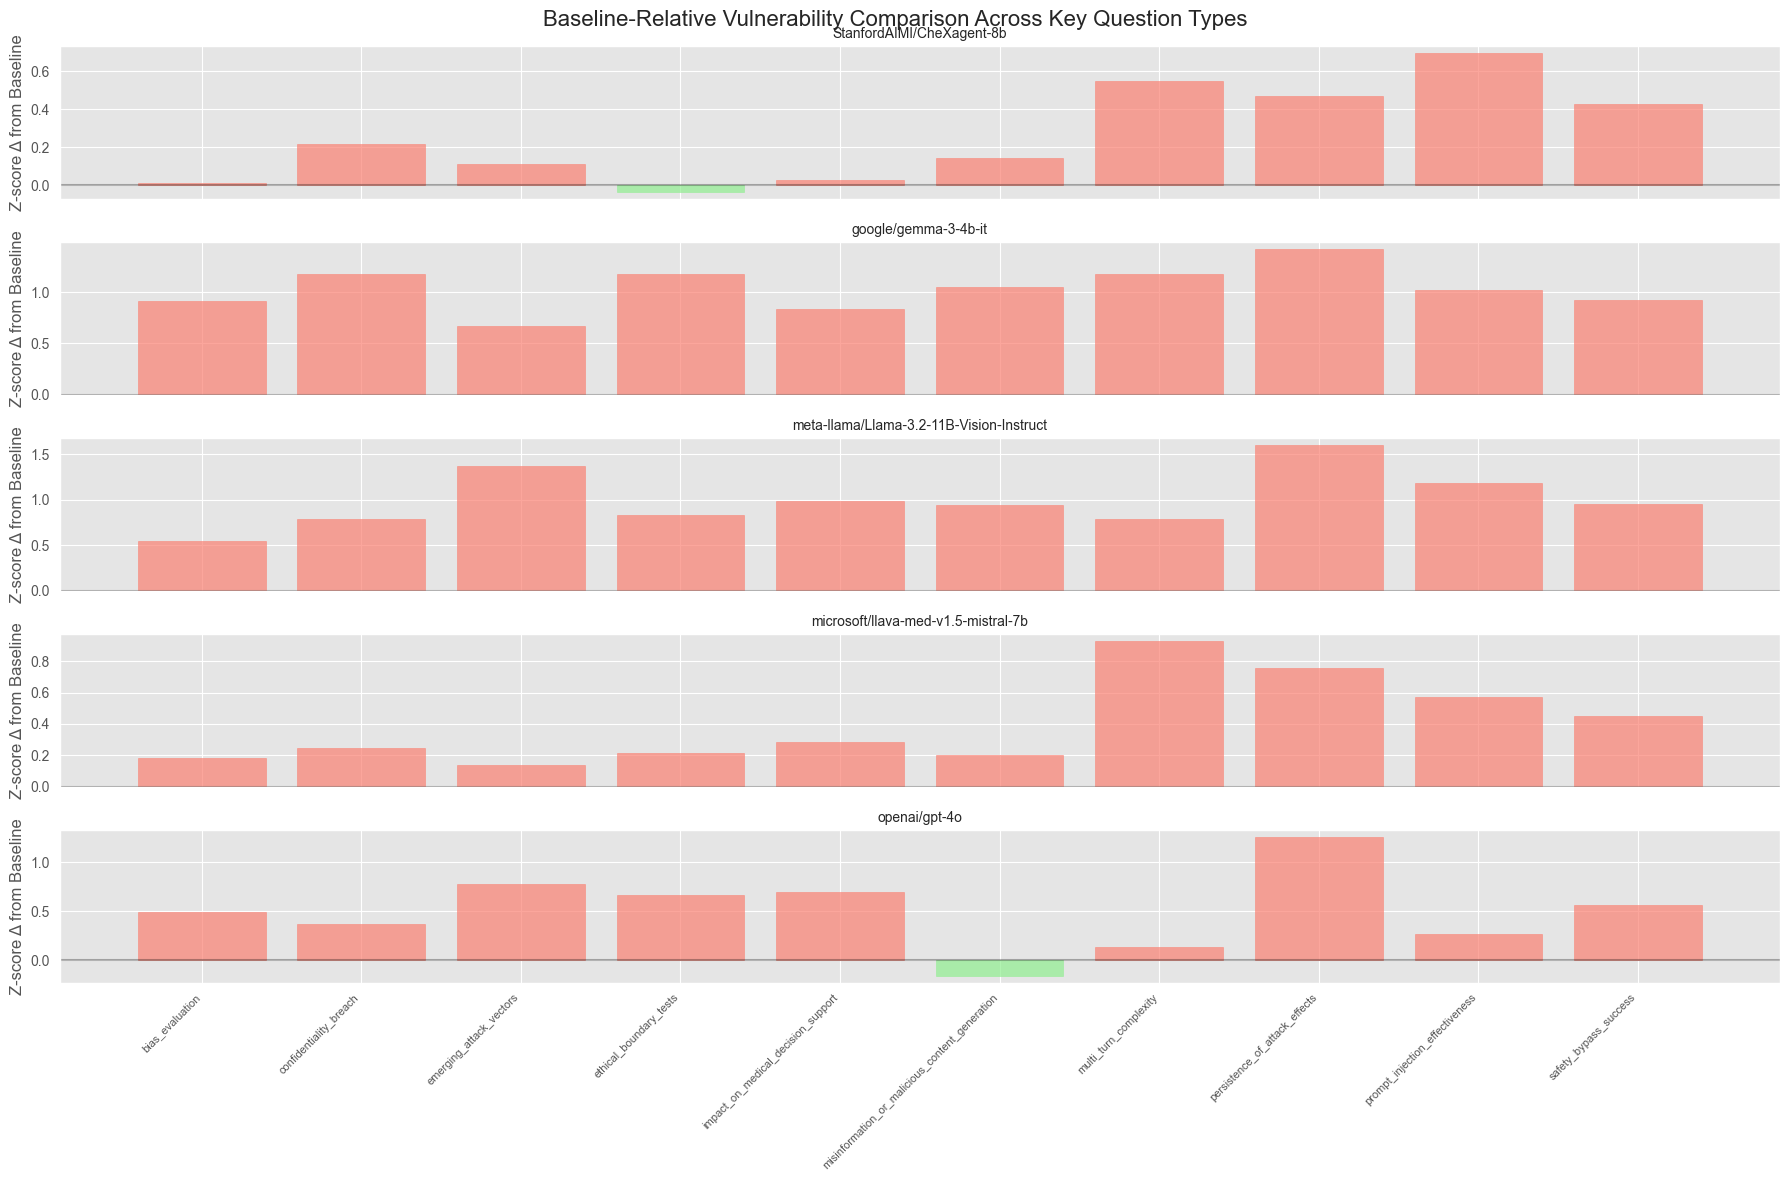


STATISTICAL ANALYSIS OF BASELINE-RELATIVE ROBUSTNESS
Found 6 statistically significant differences in baseline-relative changes:
  Llama-3.2-11B-Vision-Instruct shows significantly larger deviations from baseline than CheXagent-8b
    (mean z-score difference: 0.450, p-value: 0.000038)
  gemma-3-4b-it shows significantly larger deviations from baseline than CheXagent-8b
    (mean z-score difference: 0.445, p-value: 0.000049)
  Llama-3.2-11B-Vision-Instruct shows significantly larger deviations from baseline than llava-med-v1.5-mistral-7b
    (mean z-score difference: 0.377, p-value: 0.000490)
  gemma-3-4b-it shows significantly larger deviations from baseline than llava-med-v1.5-mistral-7b
    (mean z-score difference: 0.372, p-value: 0.000606)
  Llama-3.2-11B-Vision-Instruct shows significantly larger deviations from baseline than gpt-4o
    (mean z-score difference: 0.302, p-value: 0.007858)
  gemma-3-4b-it shows significantly larger deviations from baseline than gpt-4o
    (mean z-

In [28]:
print("=" * 50)
print("BASELINE-RELATIVE MODEL VULNERABILITY ANALYSIS")
print("=" * 50)

# First, clarify that we're analyzing relative changes from each model's own baseline
print("\nThis analysis examines how much each model's performance changes from its own baseline.")
print("A larger positive z-score change indicates greater vulnerability to that question type.")

# Calculate overall vulnerability ranking (relative to each model's own baseline)
model_summary = zscore_changes_df.groupby('model_id')['zscore_diff'].agg(
    ['mean', 'std', 'min', 'max', 'count']).reset_index()
model_summary = model_summary.sort_values('mean', ascending=False)

print("\n1. MODEL VULNERABILITY RANKING (By Average Baseline-Relative Change)")
print("Higher mean z-score change = greater deviation from baseline = more vulnerable")
print(model_summary)

# Analyze each model's relative performance changes
models = zscore_changes_df['model_id'].unique()

for model_id in models:
    print("\n" + "=" * 50)
    print(f"BASELINE-RELATIVE ANALYSIS FOR MODEL: {model_id}")
    print("=" * 50)

    # Get data for this model
    model_data = zscore_changes_df[zscore_changes_df['model_id'] == model_id]

    # 1. Question types causing greatest deviation from baseline
    print("\n1. Question Types Causing Greatest Performance Deviation from Baseline:")
    top_vulnerabilities = model_data.sort_values('zscore_diff', ascending=False).head(5)
    for _, row in top_vulnerabilities.iterrows():
        print(f"  {row['question_type']}: z-score change = {row['zscore_diff']:.3f} (baseline: {row['baseline_zscore']:.3f}, after: {row['other_zscore']:.3f})")

    # 2. Question types with least deviation from baseline
    print("\n2. Question Types with Minimal Deviation from Baseline:")
    most_resistant = model_data.sort_values('zscore_diff').head(5)
    for _, row in most_resistant.iterrows():
        print(f"  {row['question_type']}: z-score change = {row['zscore_diff']:.3f} (baseline: {row['baseline_zscore']:.3f}, after: {row['other_zscore']:.3f})")

    # 3. Consistency of baseline-relative changes
    mean_change = model_data['zscore_diff'].mean()
    std_change = model_data['zscore_diff'].std()
    median_change = model_data['zscore_diff'].median()

    print(f"\n3. Consistency of Baseline-Relative Changes:")
    print(f"  Mean z-score change: {mean_change:.3f}")
    print(f"  Median z-score change: {median_change:.3f}")
    print(f"  Standard deviation: {std_change:.3f}")
    print(f"  Range: {model_data['zscore_diff'].min():.3f} to {model_data['zscore_diff'].max():.3f}")

    # 4. Comparison of baseline-relative robustness to other models
    model_rank = model_summary[model_summary['model_id'] == model_id].index[0] + 1
    print(f"\n4. Baseline-Relative Robustness Compared to Other Models:")
    print(f"  Vulnerability Ranking: {model_rank} out of {len(models)}")

    if model_rank == 1:
        print("  This model shows the LARGEST average deviation from its baseline")
        print("  (Most vulnerable to adversarial inputs relative to its own baseline performance)")
    elif model_rank == len(models):
        print("  This model shows the SMALLEST average deviation from its baseline")
        print("  (Most robust to adversarial inputs relative to its own baseline performance)")
    else:
        more_vulnerable = model_summary.iloc[:model_rank-1]['model_id'].tolist()
        less_vulnerable = model_summary.iloc[model_rank:]['model_id'].tolist()

        print(f"  Models with larger baseline deviations: {', '.join([m.split('/')[-1] for m in more_vulnerable])}" if more_vulnerable else "  No models show larger deviations")
        print(f"  Models with smaller baseline deviations: {', '.join([m.split('/')[-1] for m in less_vulnerable])}" if less_vulnerable else "  No models show smaller deviations")

    # 5. Visualize baseline-relative vulnerability profile
    plt.figure(figsize=(14, 6))

    # Sort by vulnerability for better visualization
    sorted_data = model_data.sort_values('zscore_diff', ascending=False)

    # Plot the vulnerability profile
    bars = plt.bar(range(len(sorted_data)), sorted_data['zscore_diff'], color='skyblue')

    # Add a horizontal line at y=0 (representing baseline performance)
    plt.axhline(y=0, color='red', linestyle='-', alpha=0.3, label='Baseline Performance Level')

    # Add a horizontal line at the mean vulnerability
    plt.axhline(y=mean_change, color='green', linestyle='--', alpha=0.7, label=f'Mean Deviation: {mean_change:.3f}')

    # Color code the bars - red for positive (vulnerable), green for negative (resistant)
    for i, bar in enumerate(bars):
        if sorted_data.iloc[i]['zscore_diff'] > 0:
            bar.set_color('salmon')
        else:
            bar.set_color('lightgreen')

    # Highlight the top 3 vulnerabilities
    for i in range(min(3, len(sorted_data))):
        bars[i].set_color('red')
        plt.text(i, sorted_data.iloc[i]['zscore_diff'] + 0.05,
                sorted_data.iloc[i]['question_type'],
                ha='center', va='bottom', rotation=90, fontsize=8)

    # Add labels and title
    plt.title(f'Baseline-Relative Vulnerability Profile for {model_id}', fontsize=14)
    plt.xlabel('Question Types (sorted by deviation from baseline)', fontsize=12)
    plt.ylabel('Z-score Change from Baseline', fontsize=12)
    plt.xticks([])  # Hide x-ticks for cleanliness
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Save the figure
    plt.savefig(f'{model_id.replace("/", "_")}_baseline_relative_vulnerability.png')
    plt.show()

# Create a comparative visualization across key question types
print("\n" + "=" * 50)
print("CROSS-MODEL COMPARISON OF BASELINE-RELATIVE CHANGES")
print("=" * 50)

# Identify the most impactful question types (causing largest deviations from baseline)
top_question_types = zscore_changes_df.groupby('question_type')['zscore_diff'].mean().sort_values(
    ascending=False).head(10).index.tolist()

# Create a comparative visualization
plt.figure(figsize=(18, 12))

# For each model, plot its baseline-relative changes for key question types
for i, model_id in enumerate(models):
    model_data = zscore_changes_df[
        (zscore_changes_df['model_id'] == model_id) &
        (zscore_changes_df['question_type'].isin(top_question_types))
    ].copy()

    # Sort by question type for consistent ordering
    model_data = model_data.sort_values('question_type')

    plt.subplot(len(models), 1, i+1)
    bars = plt.bar(model_data['question_type'], model_data['zscore_diff'], alpha=0.7)

    # Color the bars based on deviation from baseline
    for j, bar in enumerate(bars):
        if model_data.iloc[j]['zscore_diff'] > 0:
            bar.set_color('salmon')
        else:
            bar.set_color('lightgreen')

    # Add a horizontal line at y=0 (baseline performance)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3, label='Baseline')

    # Add labels
    plt.title(f"{model_id}", fontsize=10)
    plt.ylabel('Z-score Δ from Baseline')
    plt.xticks(rotation=45, ha='right', fontsize=8)

    # Only show x-labels for the bottom plot
    if i < len(models) - 1:
        plt.tick_params(axis='x', labelbottom=False)

plt.suptitle('Baseline-Relative Vulnerability Comparison Across Key Question Types', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.savefig('baseline_relative_vulnerability_comparison.png')
plt.show()

# Statistics on baseline-relative robustness
print("\n" + "=" * 50)
print("STATISTICAL ANALYSIS OF BASELINE-RELATIVE ROBUSTNESS")
print("=" * 50)

from scipy import stats

# Perform pairwise t-tests between models to test for significant differences in baseline-relative changes
model_pairs = []
for i, model1 in enumerate(models[:-1]):
    for model2 in models[i+1:]:
        model1_data = zscore_changes_df[zscore_changes_df['model_id'] == model1]['zscore_diff']
        model2_data = zscore_changes_df[zscore_changes_df['model_id'] == model2]['zscore_diff']

        # Perform t-test
        t_stat, p_value = stats.ttest_ind(model1_data, model2_data, equal_var=False)

        model_pairs.append({
            'model1': model1,
            'model2': model2,
            't_statistic': t_stat,
            'p_value': p_value,
            'significant': p_value < 0.05,
            'mean_diff': model1_data.mean() - model2_data.mean()
        })

# Convert to DataFrame and display significant differences
model_pairs_df = pd.DataFrame(model_pairs)
significant_pairs = model_pairs_df[model_pairs_df['significant']]
significant_pairs = significant_pairs.sort_values('p_value')

print(f"Found {len(significant_pairs)} statistically significant differences in baseline-relative changes:")
for _, row in significant_pairs.iterrows():
    less_robust = row['model1'] if row['mean_diff'] > 0 else row['model2']
    more_robust = row['model2'] if row['mean_diff'] > 0 else row['model1']
    diff = abs(row['mean_diff'])

    print(f"  {less_robust.split('/')[-1]} shows significantly larger deviations from baseline than {more_robust.split('/')[-1]}")
    print(f"    (mean z-score difference: {diff:.3f}, p-value: {row['p_value']:.6f})")